In [1]:
# ============================================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

import os
import pandas as pd
import kagglehub


# ============================================================
# 2. CONFIGURAÇÕES DO DATASET
# ============================================================

DATASET_KAGGLE = (
    "rauffauzanrambe/"
    "fifa-world-cup-2026-player-performance-dataset"
)

ARQUIVO_ESPERADO = (
    "fifa_world_cup_2026_player_performance.csv"
)


# ============================================================
# 3. DOWNLOAD DO DATASET NO KAGGLE
# ============================================================

print("Iniciando download do dataset...")

path = kagglehub.dataset_download(
    DATASET_KAGGLE
)

print("Download concluído.")
print("Caminho onde o dataset foi salvo:")
print(path)


# ============================================================
# 4. VALIDAR SE O DIRETÓRIO EXISTE
# ============================================================

if not os.path.exists(path):
    raise FileNotFoundError(
        "O diretório retornado pelo Kaggle não foi encontrado."
    )

print("\nDiretório localizado com sucesso.")


# ============================================================
# 5. LISTAR OS ARQUIVOS DA PASTA BAIXADA
# ============================================================

arquivos = os.listdir(path)

print("\nArquivos encontrados:")

for arquivo in arquivos:
    print("•", arquivo)


# ============================================================
# 6. LOCALIZAR OS ARQUIVOS CSV
# ============================================================

csvs = [
    arquivo
    for arquivo in arquivos
    if arquivo.lower().endswith(".csv")
]

if len(csvs) == 0:
    raise FileNotFoundError(
        "Nenhum arquivo CSV foi encontrado no dataset."
    )

print(
    f"\nQuantidade de arquivos CSV encontrados: {len(csvs)}"
)


# ============================================================
# 7. SELECIONAR O CSV CORRETO
# ============================================================

if ARQUIVO_ESPERADO in csvs:

    arquivo_selecionado = ARQUIVO_ESPERADO

    print("\nArquivo esperado encontrado.")
    print(
        "CSV selecionado:",
        arquivo_selecionado
    )

elif len(csvs) == 1:

    arquivo_selecionado = csvs[0]

    print(
        "\nAtenção: o nome esperado não foi encontrado."
    )

    print(
        "Como existe apenas um CSV no diretório, "
        "ele será utilizado."
    )

    print(
        "CSV selecionado:",
        arquivo_selecionado
    )

else:

    print(
        "\nForam encontrados vários arquivos CSV:"
    )

    for arquivo in csvs:
        print("•", arquivo)

    raise ValueError(
        "Não foi possível identificar com segurança "
        "qual CSV deve ser utilizado."
    )


# ============================================================
# 8. MONTAR O CAMINHO COMPLETO DO CSV
# ============================================================

arquivo_csv = os.path.join(
    path,
    arquivo_selecionado
)

if not os.path.isfile(arquivo_csv):
    raise FileNotFoundError(
        "O arquivo CSV selecionado não foi localizado."
    )

print("\nCaminho completo do CSV:")
print(arquivo_csv)


# ============================================================
# 9. VERIFICAR O TAMANHO DO ARQUIVO
# ============================================================

tamanho_mb = (
    os.path.getsize(arquivo_csv)
    / 1024**2
)

print(
    f"\nTamanho do arquivo CSV: {tamanho_mb:.2f} MB"
)


# ============================================================
# 10. CARREGAR O CSV COM PANDAS
# ============================================================

print("\nCarregando os dados...")

df = pd.read_csv(
    arquivo_csv
)

print("Arquivo carregado com sucesso.")


# ============================================================
# 11. VALIDAR DIMENSÕES DA BASE
# ============================================================

print("\nDIMENSÕES DA BASE")

print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

if df.shape[1] == 75:

    print(
        "Validação OK: a base possui 75 colunas."
    )

else:

    print(
        "Atenção: quantidade de colunas diferente "
        "das 75 esperadas."
    )


# ============================================================
# 12. MOSTRAR AS PRIMEIRAS LINHAS
# ============================================================

print("\nPRIMEIRAS 5 LINHAS")

display(
    df.head()
)


# ============================================================
# 13. MOSTRAR NOMES DAS COLUNAS
# ============================================================

print("\nCOLUNAS DA BASE")

for numero, coluna in enumerate(
    df.columns,
    start=1
):

    print(
        numero,
        coluna
    )


# ============================================================
# 14. INFORMAÇÕES GERAIS DA BASE
# ============================================================

print("\nINFORMAÇÕES GERAIS")

df.info()


# ============================================================
# 15. MEMÓRIA UTILIZADA PELO DATAFRAME
# ============================================================

memoria_mb = (
    df.memory_usage(
        deep=True
    ).sum()
    / 1024**2
)

print(
    f"\nMemória utilizada pelo DataFrame: "
    f"{memoria_mb:.2f} MB"
)


# ============================================================
# 16. QUANTIDADE TOTAL DE VALORES NULOS
# ============================================================

total_nulos = (
    df.isnull()
    .sum()
    .sum()
)

print(
    "\nTotal de valores nulos:",
    total_nulos
)


# ============================================================
# 17. VERIFICAR NOMES DE COLUNAS DUPLICADOS
# ============================================================

colunas_duplicadas = (
    df.columns[
        df.columns.duplicated()
    ]
    .tolist()
)

if len(colunas_duplicadas) == 0:

    print(
        "\nValidação OK: não existem nomes "
        "de colunas duplicados."
    )

else:

    print(
        "\nAtenção: foram encontrados nomes "
        "de colunas duplicados:"
    )

    print(
        colunas_duplicadas
    )


# ============================================================
# 18. RESUMO FINAL
# ============================================================

print("\n====================================")
print("RESUMO DA CARGA")
print("====================================")


print(
    "Dataset Kaggle:",
    DATASET_KAGGLE
)

print(
    "Arquivo:",
    arquivo_selecionado
)

print(
    f"Tamanho do arquivo: "
    f"{tamanho_mb:.2f} MB"
)

print(
    "Linhas:",
    df.shape[0]
)

print(
    "Colunas:",
    df.shape[1]
)

print(
    f"Memória do DataFrame: "
    f"{memoria_mb:.2f} MB"
)

print(
    "Valores nulos:",
    total_nulos
)

print(
    "Colunas duplicadas:",
    len(colunas_duplicadas)
)

print("====================================")


Iniciando download do dataset...
Download concluído.
Caminho onde o dataset foi salvo:
C:\Users\li_fr\.cache\kagglehub\datasets\rauffauzanrambe\fifa-world-cup-2026-player-performance-dataset\versions\1

Diretório localizado com sucesso.

Arquivos encontrados:
• fifa_world_cup_2026_player_performance.csv

Quantidade de arquivos CSV encontrados: 1

Arquivo esperado encontrado.
CSV selecionado: fifa_world_cup_2026_player_performance.csv

Caminho completo do CSV:
C:\Users\li_fr\.cache\kagglehub\datasets\rauffauzanrambe\fifa-world-cup-2026-player-performance-dataset\versions\1\fifa_world_cup_2026_player_performance.csv

Tamanho do arquivo CSV: 16.40 MB

Carregando os dados...
Arquivo carregado com sucesso.

DIMENSÕES DA BASE
Linhas: 54600
Colunas: 75
Validação OK: a base possui 75 colunas.

PRIMEIRAS 5 LINHAS


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7



COLUNAS DA BASE
1 player_id
2 player_name
3 age
4 nationality
5 team
6 jersey_number
7 position
8 height_cm
9 weight_kg
10 preferred_foot
11 club_name
12 market_value_eur
13 match_id
14 match_date
15 stadium
16 city
17 opponent_team
18 tournament_stage
19 match_result
20 goals_team
21 goals_opponent
22 minutes_played
23 goals
24 assists
25 shots
26 shots_on_target
27 expected_goals_xg
28 expected_assists_xa
29 key_passes
30 successful_passes
31 total_passes
32 pass_accuracy
33 dribbles_attempted
34 successful_dribbles
35 crosses
36 successful_crosses
37 tackles
38 interceptions
39 clearances
40 blocks
41 aerial_duels_won
42 aerial_duels_lost
43 recoveries
44 defensive_actions
45 fouls_committed
46 fouls_suffered
47 yellow_cards
48 red_cards
49 offsides
50 saves
51 save_percentage
52 punches
53 clean_sheet
54 goals_conceded
55 penalty_saves
56 distance_covered_km
57 sprint_distance_km
58 top_speed_kmh
59 accelerations
60 decelerations
61 stamina_score
62 player_rating
63 performance_sc

PARTE 1 — PRIMEIRO CONTATO E CONFERÊNCIA DOS DADOS

Nesta parte, vou conhecer melhor os dados, verificar quanto espaço eles ocupam na memória e procurar possíveis problemas antes de começar as análises.

T1.1 — Tamanho e memória

Vou verificar quantas linhas e colunas a base tem e quanto espaço ela ocupa na memória.

Depois, vou testar outra forma de armazenar as informações para ver se consigo reduzir esse espaço. O teste será feito em uma cópia, sem alterar a base original.

In [2]:
print("====================================")
print("T1.1 - TAMANHO E MEMÓRIA")
print("====================================")

print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

memoria_original_mb = (
    df.memory_usage(deep=True).sum()
    / 1024**2
)

print(
    f"Memória original: "
    f"{memoria_original_mb:.2f} MB"
)

T1.1 - TAMANHO E MEMÓRIA
Linhas: 54600
Colunas: 75
Memória original: 37.38 MB


In [3]:
df_otimizado = df.copy()

print("Cópia criada com sucesso.")

Cópia criada com sucesso.


In [4]:
colunas_texto = (
    df_otimizado
    .select_dtypes(
        include=["object", "string"]
    )
    .columns
)

print("Colunas de texto encontradas:")
print(list(colunas_texto))

Colunas de texto encontradas:
['player_id', 'player_name', 'nationality', 'team', 'position', 'preferred_foot', 'club_name', 'match_id', 'match_date', 'stadium', 'city', 'opponent_team', 'tournament_stage', 'match_result']


In [5]:
for coluna in colunas_texto:

    quantidade_unicos = df_otimizado[coluna].nunique()

    proporcao_unicos = (
        quantidade_unicos
        / len(df_otimizado)
    )

    print(
        coluna,
        "->",
        quantidade_unicos,
        "valores únicos |",
        f"{proporcao_unicos:.2%}"
    )

player_id -> 1248 valores únicos | 2.29%
player_name -> 1245 valores únicos | 2.28%
nationality -> 48 valores únicos | 0.09%
team -> 48 valores únicos | 0.09%
position -> 4 valores únicos | 0.01%
preferred_foot -> 2 valores únicos | 0.00%
club_name -> 122 valores únicos | 0.22%
match_id -> 1050 valores únicos | 1.92%
match_date -> 51 valores únicos | 0.09%
stadium -> 16 valores únicos | 0.03%
city -> 16 valores únicos | 0.03%
opponent_team -> 48 valores únicos | 0.09%
tournament_stage -> 7 valores únicos | 0.01%
match_result -> 3 valores únicos | 0.01%


In [6]:
for coluna in colunas_texto:
    df_otimizado[coluna] = (
        df_otimizado[coluna]
        .astype("category")
    )

print("Colunas de texto convertidas para category.")

Colunas de texto convertidas para category.


In [7]:
memoria_otimizada_mb = (
    df_otimizado
    .memory_usage(deep=True)
    .sum()
    / 1024**2
)

reducao_percentual = (
    (
        memoria_original_mb
        - memoria_otimizada_mb
    )
    / memoria_original_mb
    * 100
)

print(
    f"Memória original: "
    f"{memoria_original_mb:.2f} MB"
)

print(
    f"Memória otimizada: "
    f"{memoria_otimizada_mb:.2f} MB"
)

print(
    f"Redução de memória: "
    f"{reducao_percentual:.2f}%"
)

Memória original: 37.38 MB
Memória otimizada: 26.36 MB
Redução de memória: 29.48%


Conclusão do T1.1

A base tem 54.600 linhas e 75 colunas e ocupa 37,38 MB de memória.

Em uma cópia da base, testei uma forma de armazenar os textos que se repetem usando menos memória.

Com essa mudança, o consumo caiu para 26,36 MB, uma redução de 29,48%.

O teste foi feito sem alterar a base original.

T1.2 — Conferência das colunas

Vou conferir as 75 colunas da base. Em cada uma, vou observar:

o tipo de informação, como texto ou número;

quantos valores estão faltando e qual a porcentagem;

quantos valores diferentes aparecem.

Essa conferência vai ajudar a identificar informações que precisam de mais atenção antes de seguir com as análises.

In [8]:
mapa_qualidade = pd.DataFrame({
    "coluna": df.columns,

    "tipo": [
        str(df[coluna].dtype)
        for coluna in df.columns
    ],

    "nulos": [
        df[coluna].isna().sum()
        for coluna in df.columns
    ],

    "percentual_nulos": [
        df[coluna].isna().mean() * 100
        for coluna in df.columns
    ],

    "cardinalidade": [
        df[coluna].nunique(dropna=False)
        for coluna in df.columns
    ]
})

display(mapa_qualidade)

,coluna,tipo,nulos,percentual_nulos,cardinalidade
0,player_id,str,0,0.0,1248
1,player_name,str,0,0.0,1245
2,age,int64,0,0.0,23
3,nationality,str,0,0.0,48
4,team,str,0,0.0,48
...,...,...,...,...,...
70,total_goals_tournament,int64,0,0.0,11
71,total_assists_tournament,int64,0,0.0,9
72,total_minutes_tournament,int64,0,0.0,586
73,player_of_match_awards,int64,0,0.0,5


In [9]:
mapa_qualidade_ordenado = (
    mapa_qualidade
    .sort_values(
        by="cardinalidade",
        ascending=False
    )
)

display(
    mapa_qualidade_ordenado.head(15)
)

,coluna,tipo,nulos,percentual_nulos,cardinalidade
0,player_id,str,0,0.0,1248
11,market_value_eur,int64,0,0.0,1246
1,player_name,str,0,0.0,1245
12,match_id,str,0,0.0,1050
63,offensive_contribution,float64,0,0.0,981
64,defensive_contribution,float64,0,0.0,941
67,creativity_score,float64,0,0.0,941
69,clutch_performance_score,float64,0,0.0,829
66,pressure_resistance,float64,0,0.0,815
68,consistency_score,float64,0,0.0,738


In [10]:
colunas_constantes = (
    mapa_qualidade[
        mapa_qualidade["cardinalidade"] == 1
    ]
)

display(colunas_constantes)

,coluna,tipo,nulos,percentual_nulos,cardinalidade


In [11]:
baixa_cardinalidade = (
    mapa_qualidade[
        mapa_qualidade["cardinalidade"] <= 10
    ]
    .sort_values(
        by="cardinalidade",
        ascending=True
    )
)

display(baixa_cardinalidade)

,coluna,tipo,nulos,percentual_nulos,cardinalidade
9,preferred_foot,str,0,0.0,2
54,penalty_saves,int64,0,0.0,2
46,yellow_cards,int64,0,0.0,2
47,red_cards,int64,0,0.0,2
52,clean_sheet,int64,0,0.0,2
18,match_result,str,0,0.0,3
35,successful_crosses,int64,0,0.0,3
6,position,str,0,0.0,4
23,assists,int64,0,0.0,4
51,punches,int64,0,0.0,4


In [12]:
print("VALORES DA COLUNA position")
print(df["position"].value_counts())

print("\nVALORES DA COLUNA preferred_foot")
print(df["preferred_foot"].value_counts())

VALORES DA COLUNA position
position
Defender      18900
Midfielder    16800
Forward       12600
Goalkeeper     6300
Name: count, dtype: int64

VALORES DA COLUNA preferred_foot
preferred_foot
Right    40656
Left     13944
Name: count, dtype: int64


In [13]:
print("VALORES DA COLUNA tournament_stage")
print(df["tournament_stage"].value_counts())

print("\nVALORES DA COLUNA match_result")
print(df["match_result"].value_counts())

VALORES DA COLUNA tournament_stage
tournament_stage
Group Stage          30056
Round of 32           9256
Round of 16           6552
Quarter Finals        4368
Semi Finals           2184
Third Place Match     1092
Final                 1092
Name: count, dtype: int64

VALORES DA COLUNA match_result
match_result
W    20124
L    20124
D    14352
Name: count, dtype: int64


In [14]:
ids_por_nome = (
    df.groupby("player_name")["player_id"]
    .nunique()
)

nomes_com_multiplos_ids = (
    ids_por_nome[
        ids_por_nome > 1
    ]
)

print("Jogadores com mais de um player_id:")
print(nomes_com_multiplos_ids)

print(
    "\nQuantidade de nomes com mais de um ID:",
    len(nomes_com_multiplos_ids)
)

Jogadores com mais de um player_id:
player_name
Hee-chan Hwang              2
Kalidou Mendy               2
Pierre-Emile Christensen    2
Name: player_id, dtype: int64

Quantidade de nomes com mais de um ID: 3


In [15]:
nomes_investigar = [
    "Hee-chan Hwang",
    "Kalidou Mendy",
    "Pierre-Emile Christensen"
]

investigacao_ids = (
    df[
        df["player_name"].isin(nomes_investigar)
    ][
        [
            "player_name",
            "player_id",
            "age",
            "nationality",
            "team",
            "position",
            "club_name"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        by=[
            "player_name",
            "player_id"
        ]
    )
)

display(investigacao_ids)

,player_name,player_id,age,nationality,team,position,club_name
1480,Hee-chan Hwang,P00834,31,South Korean,South Korea,Goalkeeper,Al-Ahli
1462,Hee-chan Hwang,P00837,28,South Korean,South Korea,Defender,Pohang Steelers
154,Kalidou Mendy,P01016,25,Senegalese,Senegal,Goalkeeper,TP Mazembe
136,Kalidou Mendy,P01019,25,Senegalese,Senegal,Defender,ES Tunis
337,Pierre-Emile Christensen,P00262,32,Danish,Denmark,Goalkeeper,Anderlecht
335,Pierre-Emile Christensen,P00274,21,Danish,Denmark,Midfielder,Anderlecht


### Nomes repetidos na base

Encontrei 1.245 nomes diferentes na coluna player_name e 1.248 códigos na coluna player_id.

Ao conferir essa diferença, vi que 3 nomes aparecem com mais de um código. Esses registros também têm diferenças em informações como idade, posição e clube.

Por isso, usar apenas o nome pode misturar informações de jogadores que a base apresenta como diferentes. Nas análises, vou usar o player_id para identificar cada jogador.

In [16]:
datas_convertidas = pd.to_datetime(
    df["match_date"],
    errors="coerce"
)

datas_invalidas = datas_convertidas.isna().sum()

print(
    "Quantidade de datas que não puderam ser convertidas:",
    datas_invalidas
)

print("\nPrimeiras datas da base:")
print(df["match_date"].head(10))

Quantidade de datas que não puderam ser convertidas: 0

Primeiras datas da base:
0    2026-07-10
1    2026-07-10
2    2026-07-10
3    2026-07-10
4    2026-07-10
5    2026-07-10
6    2026-07-10
7    2026-07-10
8    2026-07-10
9    2026-07-10
Name: match_date, dtype: str


### Conferência das datas das partidas

A coluna match_date contém as datas das partidas, mas está armazenada como texto.

Fiz um teste para que o Python reconhecesse esses valores como datas, e todos foram convertidos sem erro.

Isso facilita organizar as partidas por data, mas ainda não garante que as datas registradas estejam corretas. Essa conferência será feita nas próximas etapas.

In [17]:
print("Valores de save_percentage por posição")

resumo_save_percentage = (
    df.groupby("position")["save_percentage"]
    .agg(
        quantidade_registros="count",
        minimo="min",
        maximo="max",
        media="mean"
    )
)

display(resumo_save_percentage)

Valores de save_percentage por posição


,quantidade_registros,minimo,maximo,media
position,,,,
Defender,18900,0.0,0.0,0.00000
Forward,12600,0.0,0.0,0.00000
Goalkeeper,6300,0.0,1.0,0.22771
Midfielder,16800,0.0,0.0,0.00000


### Conferência do aproveitamento em defesas

A coluna save_percentage mostra o aproveitamento em defesas. Todos os jogadores de linha aparecem com zero nessa coluna, e apenas goleiros têm valores diferentes de zero.

É preciso cuidado ao interpretar esse zero. Para um goleiro, ele pode indicar que não conseguiu defender os chutes recebidos. Para um jogador de linha, essa informação não se aplica.

Por isso, ao analisar o aproveitamento em defesas, vou considerar apenas os goleiros e verificar se eles tiveram participação na partida.

In [18]:
minutos_por_jogador = (
    df.groupby("player_id")["minutes_played"]
    .sum()
)

minutos_torneio_informados = (
    df.groupby("player_id")["total_minutes_tournament"]
    .max()
)

comparacao_minutos = pd.DataFrame({
    "minutos_somados_partidas": minutos_por_jogador,
    "total_minutes_tournament": minutos_torneio_informados
})

comparacao_minutos["diferenca"] = (
    comparacao_minutos["minutos_somados_partidas"]
    - comparacao_minutos["total_minutes_tournament"]
)

print(
    "Jogadores com diferença entre os minutos:",
    (comparacao_minutos["diferenca"] != 0).sum()
)

display(
    comparacao_minutos[
        comparacao_minutos["diferenca"] != 0
    ].head(20)
)

Jogadores com diferença entre os minutos: 1248


,minutos_somados_partidas,total_minutes_tournament,diferenca
player_id,,,
P00001,953,516,437
P00002,830,485,345
P00003,922,543,379
P00004,1299,557,742
P00005,1298,522,776
P00006,1372,477,895
P00007,1173,547,626
P00008,1449,518,931
P00009,1722,503,1219


In [19]:
jogador_teste = df[
    df["player_id"] == "P00001"
][
    [
        "player_id",
        "player_name",
        "match_id",
        "match_date",
        "minutes_played",
        "total_minutes_tournament"
    ]
]

display(jogador_teste)

print(
    "\nQuantidade de partidas registradas:",
    jogador_teste["match_id"].nunique()
)

print(
    "Soma de minutes_played:",
    jogador_teste["minutes_played"].sum()
)

print(
    "Valores diferentes de total_minutes_tournament:",
    jogador_teste["total_minutes_tournament"].unique()
)

,player_id,player_name,match_id,match_date,minutes_played,total_minutes_tournament
1246,P00001,Kylian Griezmann,M00024,2026-07-24,0,348
4626,P00001,Kylian Griezmann,M00089,2026-07-02,0,78
9176,P00001,Kylian Griezmann,M00177,2026-07-12,0,405
9827,P00001,Kylian Griezmann,M00189,2026-07-14,0,426
10790,P00001,Kylian Griezmann,M00208,2026-07-17,81,338
11492,P00001,Kylian Griezmann,M00222,2026-07-09,61,453
12790,P00001,Kylian Griezmann,M00246,2026-07-23,0,23
14012,P00001,Kylian Griezmann,M00270,2026-06-20,0,172
14974,P00001,Kylian Griezmann,M00288,2026-07-10,0,401
15366,P00001,Kylian Griezmann,M00296,2026-07-17,50,283



Quantidade de partidas registradas: 34
Soma de minutes_played: 953
Valores diferentes de total_minutes_tournament: [348  78 405 426 338 453  23 172 401 283 236 166 245  77 431 132 406 218
 237 479 456 294 228 362 345 235 361 516 374 146 147  62 398 127]


In [20]:
jogador_teste_ordenado = jogador_teste.copy()

jogador_teste_ordenado["match_date"] = pd.to_datetime(
    jogador_teste_ordenado["match_date"]
)

jogador_teste_ordenado = (
    jogador_teste_ordenado
    .sort_values("match_date")
)

jogador_teste_ordenado["minutos_acumulados_calculados"] = (
    jogador_teste_ordenado["minutes_played"]
    .cumsum()
)

display(
    jogador_teste_ordenado[
        [
            "match_date",
            "match_id",
            "minutes_played",
            "minutos_acumulados_calculados",
            "total_minutes_tournament"
        ]
    ]
)

,match_date,match_id,minutes_played,minutos_acumulados_calculados,total_minutes_tournament
47216,2026-06-13,M00909,80,80,374
49294,2026-06-14,M00948,0,80,398
36400,2026-06-19,M00701,84,164,479
14012,2026-06-20,M00270,0,164,172
46670,2026-06-21,M00898,74,238,516
31408,2026-06-21,M00605,62,300,132
47709,2026-06-23,M00918,0,300,146
35488,2026-06-23,M00683,0,300,237
45993,2026-06-24,M00885,0,300,235
41365,2026-06-24,M00796,0,300,294


In [21]:
partidas_por_jogador = (
    df.groupby("player_id")["match_id"]
    .nunique()
    .sort_values(ascending=False)
)

print("Maior quantidade de partidas de um jogador:")
print(partidas_por_jogador.max())

print("\nMenor quantidade de partidas de um jogador:")
print(partidas_por_jogador.min())

print("\nMédia de partidas por jogador:")
print(round(partidas_por_jogador.mean(), 2))

print("\n10 jogadores com mais partidas:")
display(
    partidas_por_jogador.head(10)
)

Maior quantidade de partidas de um jogador:
66

Menor quantidade de partidas de um jogador:
33

Média de partidas por jogador:
43.75

10 jogadores com mais partidas:


player_id
P00962    66
P00961    66
P00960    66
P00959    66
P00958    66
P00957    66
P00941    66
P00942    66
P00943    66
P00944    66
Name: match_id, dtype: int64

### Conferência dos minutos e da quantidade de partidas

Encontrei uma quantidade de partidas por jogador maior do que seria esperado em uma única Copa do Mundo:

mínimo de 33 partidas;

média de 43,75 partidas;

máximo de 66 partidas.

Essas são partidas associadas ao jogador na base, incluindo aquelas em que ele aparece com zero minuto em campo.

Também encontrei diferenças entre a soma dos minutos de cada jogador e o valor informado em total_minutes_tournament.

Ao olhar um jogador como exemplo, percebi que esse valor aumenta e diminui entre as partidas. Isso não é o esperado de um total que vai acumulando os minutos jogados.

Por isso, preciso entender como essa coluna foi preenchida antes de confiar nela para as próximas análises.

In [22]:
partidas_por_jogador_data = (
    df.groupby(
        [
            "player_id",
            "match_date"
        ]
    )["match_id"]
    .nunique()
    .reset_index(
        name="quantidade_partidas"
    )
)

jogador_multiplas_partidas_dia = (
    partidas_por_jogador_data[
        partidas_por_jogador_data[
            "quantidade_partidas"
        ] > 1
    ]
)

print(
    "Quantidade de casos em que um jogador "
    "aparece em mais de uma partida no mesmo dia:",
    len(jogador_multiplas_partidas_dia)
)

print(
    "\nMaior quantidade de partidas atribuídas "
    "ao mesmo jogador no mesmo dia:",
    jogador_multiplas_partidas_dia[
        "quantidade_partidas"
    ].max()
)

display(
    jogador_multiplas_partidas_dia.head(20)
)

Quantidade de casos em que um jogador aparece em mais de uma partida no mesmo dia: 13546

Maior quantidade de partidas atribuídas ao mesmo jogador no mesmo dia: 5


,player_id,match_date,quantidade_partidas
4,P00001,2026-06-21,2
5,P00001,2026-06-23,2
6,P00001,2026-06-24,2
9,P00001,2026-06-30,2
11,P00001,2026-07-03,2
18,P00001,2026-07-12,2
21,P00001,2026-07-17,2
31,P00002,2026-06-21,2
32,P00002,2026-06-23,2
33,P00002,2026-06-24,2


In [23]:
caso_exemplo = df[
    (df["player_id"] == "P00001")
    &
    (df["match_date"] == "2026-06-21")
][
    [
        "player_id",
        "player_name",
        "match_date",
        "match_id",
        "team",
        "opponent_team",
        "tournament_stage",
        "minutes_played",
        "goals_team",
        "goals_opponent",
        "match_result"
    ]
]

display(caso_exemplo)

,player_id,player_name,match_date,match_id,team,opponent_team,tournament_stage,minutes_played,goals_team,goals_opponent,match_result
31408,P00001,Kylian Griezmann,2026-06-21,M00605,France,Qatar,Round of 32,62,2,2,D
46670,P00001,Kylian Griezmann,2026-06-21,M00898,France,Tunisia,Quarter Finals,74,3,1,W


In [24]:
resumo_match_id = (
    df.groupby("match_id")
    .agg(
        datas_diferentes=("match_date", "nunique"),
        times_diferentes=("team", "nunique"),
        adversarios_diferentes=("opponent_team", "nunique"),
        fases_diferentes=("tournament_stage", "nunique")
    )
)

print("Match IDs com mais de uma data:")
print(
    (resumo_match_id["datas_diferentes"] > 1).sum()
)

print("\nMatch IDs com mais de uma fase:")
print(
    (resumo_match_id["fases_diferentes"] > 1).sum()
)

print("\nMatch IDs com mais de dois times:")
print(
    (resumo_match_id["times_diferentes"] > 2).sum()
)

display(
    resumo_match_id.head(20)
)

Match IDs com mais de uma data:
0

Match IDs com mais de uma fase:
0

Match IDs com mais de dois times:
0


,datas_diferentes,times_diferentes,adversarios_diferentes,fases_diferentes
match_id,,,,
M00001,1,2,2,1
M00002,1,2,2,1
M00003,1,2,2,1
M00004,1,2,2,1
M00005,1,2,2,1
M00006,1,2,2,1
M00007,1,2,2,1
M00008,1,2,2,1
M00009,1,2,2,1


In [25]:
comparacao_datas = pd.DataFrame({
    "data_original_texto": df["match_date"],
    "data_convertida": pd.to_datetime(
        df["match_date"],
        errors="coerce"
    )
})

comparacao_datas["data_convertida_texto"] = (
    comparacao_datas["data_convertida"]
    .dt.strftime("%Y-%m-%d")
)

comparacao_datas["iguais"] = (
    comparacao_datas["data_original_texto"]
    ==
    comparacao_datas["data_convertida_texto"]
)

print(
    "Quantidade de datas diferentes após conversão:",
    (~comparacao_datas["iguais"]).sum()
)

display(
    comparacao_datas[
        comparacao_datas["iguais"] == False
    ].head(20)
)

Quantidade de datas diferentes após conversão: 0


,data_original_texto,data_convertida,data_convertida_texto,iguais


In [26]:
verificacao_data_original = df[
    (df["player_id"] == "P00001")
    &
    (df["match_date"] == "2026-06-21")
][
    [
        "player_id",
        "player_name",
        "match_date",
        "match_id",
        "team",
        "opponent_team",
        "tournament_stage",
        "minutes_played"
    ]
]

display(verificacao_data_original)

,player_id,player_name,match_date,match_id,team,opponent_team,tournament_stage,minutes_played
31408,P00001,Kylian Griezmann,2026-06-21,M00605,France,Qatar,Round of 32,62
46670,P00001,Kylian Griezmann,2026-06-21,M00898,France,Tunisia,Quarter Finals,74


### Conferência das datas e partidas

Encontrei jogadores que aparecem em mais de uma partida no mesmo dia.

Primeiro, conferi se isso poderia ter acontecido ao transformar os textos da coluna `match_date` em datas. Comparei os 54.600 valores antes e depois da conversão e não encontrei nenhuma diferença.

Também fiz a busca usando os textos originais. O jogador `P00001` continuou aparecendo em duas partidas no dia 21/06/2026:

* França x Qatar, na fase de 32 seleções;
* França x Tunísia, nas quartas de final.

Isso mostra que a situação já estava na base e não foi causada pela conversão das datas.

Ao conferir os códigos das partidas, não encontrei nenhum ligado a mais de uma data, mais de uma fase ou mais de dois times.

O ponto que precisa ser esclarecido é por que o mesmo jogador aparece em partidas diferentes no mesmo dia.

 
### Conclusão do T1.2 — O que encontrei na conferência

Não encontrei valores faltando nem colunas com um único valor repetido em todas as linhas. Mesmo assim, alguns pontos precisam de atenção.

#### 1. O nome não é suficiente para identificar um jogador

A base tem 1.245 nomes diferentes e 1.248 códigos de jogador.

Encontrei 3 nomes que aparecem com códigos diferentes e também apresentam diferenças em informações como idade, posição e clube.

Por isso, vou usar `player_id` para identificar os jogadores e evitar misturar registros apenas porque têm o mesmo nome.

#### 2. Há jogadores associados a várias partidas no mesmo dia

Encontrei 13.546 casos em que um jogador aparece em mais de uma partida na mesma data, chegando a 5 partidas em um dia. Esse número representa combinações de jogador e data, não jogadores diferentes.

Por exemplo, o jogador `P00001` aparece em duas partidas em 21/06/2026:

* França x Qatar, na fase de 32 seleções;
* França x Tunísia, nas quartas de final.

Conferi os dados antes e depois da conversão das datas e obtive o mesmo resultado. Portanto, essa situação já estava na base original.

#### 3. Os minutos informados precisam de mais explicação

Para cada jogador, comparei a soma de `minutes_played` com o maior valor informado em `total_minutes_tournament`. Os valores foram diferentes para todos os jogadores.

Depois, ao acompanhar as partidas de um jogador em ordem de data, vi que `total_minutes_tournament` aumenta e diminui. Isso não é o esperado de um total que acumula os minutos jogados.

Além disso, cada jogador aparece associado a 33 até 66 partidas, com média de 43,75. Essa contagem inclui partidas em que ele aparece com zero minuto em campo e não parece compatível com uma única Copa do Mundo.

Antes de confiar nesses totais, preciso entender como foram preenchidos.

#### Sobre o formato das datas

A coluna `match_date` está armazenada como texto. O teste de conversão para data funcionou sem alterar os valores.

Essa mudança facilita trabalhar com as datas, mas não resolve os problemas encontrados nas partidas e nos minutos.

## T1.3 — Organização das colunas em 10 grupos

Vou organizar as 75 colunas da base em 10 grupos, de acordo com o assunto de cada uma.

Depois, vou escolher uma coluna de cada grupo e explicar o que ela informa e como seu valor é medido, por exemplo, em minutos, anos ou quilômetros.

In [27]:
grupos_variaveis = {
    "1. Identificação e perfil": [
        "player_id",
        "player_name",
        "age",
        "nationality",
        "team",
        "jersey_number",
        "position",
        "height_cm",
        "weight_kg",
        "preferred_foot",
        "club_name",
        "market_value_eur"
    ],

    "2. Contexto da partida": [
        "match_id",
        "match_date",
        "stadium",
        "city",
        "opponent_team",
        "tournament_stage",
        "match_result",
        "goals_team",
        "goals_opponent",
        "minutes_played"
    ],

    "3. Produção ofensiva e criação": [
        "goals",
        "assists",
        "shots",
        "shots_on_target",
        "expected_goals_xg",
        "expected_assists_xa",
        "key_passes"
    ],

    "4. Passes": [
        "successful_passes",
        "total_passes",
        "pass_accuracy"
    ],

    "5. Dribles e cruzamentos": [
        "dribbles_attempted",
        "successful_dribbles",
        "crosses",
        "successful_crosses"
    ],

    "6. Defesa e disciplina": [
        "tackles",
        "interceptions",
        "clearances",
        "blocks",
        "aerial_duels_won",
        "aerial_duels_lost",
        "recoveries",
        "defensive_actions",
        "fouls_committed",
        "fouls_suffered",
        "yellow_cards",
        "red_cards",
        "offsides"
    ],

    "7. Estatísticas de goleiro": [
        "saves",
        "save_percentage",
        "punches",
        "clean_sheet",
        "goals_conceded",
        "penalty_saves"
    ],

    "8. Desempenho físico": [
        "distance_covered_km",
        "sprint_distance_km",
        "top_speed_kmh",
        "accelerations",
        "decelerations",
        "stamina_score"
    ],

    "9. Indicadores de performance": [
        "player_rating",
        "performance_score",
        "offensive_contribution",
        "defensive_contribution",
        "possession_impact",
        "pressure_resistance",
        "creativity_score",
        "consistency_score",
        "clutch_performance_score"
    ],

    "10. Acumulados do torneio": [
        "total_goals_tournament",
        "total_assists_tournament",
        "total_minutes_tournament",
        "player_of_match_awards",
        "tournament_rating"
    ]
}

In [28]:
for grupo, colunas in grupos_variaveis.items():

    print("\n====================================")
    print(grupo)
    print("====================================")

    for coluna in colunas:
        print("•", coluna)


1. Identificação e perfil
• player_id
• player_name
• age
• nationality
• team
• jersey_number
• position
• height_cm
• weight_kg
• preferred_foot
• club_name
• market_value_eur

2. Contexto da partida
• match_id
• match_date
• stadium
• city
• opponent_team
• tournament_stage
• match_result
• goals_team
• goals_opponent
• minutes_played

3. Produção ofensiva e criação
• goals
• assists
• shots
• shots_on_target
• expected_goals_xg
• expected_assists_xa
• key_passes

4. Passes
• successful_passes
• total_passes
• pass_accuracy

5. Dribles e cruzamentos
• dribbles_attempted
• successful_dribbles
• crosses
• successful_crosses

6. Defesa e disciplina
• tackles
• interceptions
• clearances
• blocks
• aerial_duels_won
• aerial_duels_lost
• recoveries
• defensive_actions
• fouls_committed
• fouls_suffered
• yellow_cards
• red_cards
• offsides

7. Estatísticas de goleiro
• saves
• save_percentage
• punches
• clean_sheet
• goals_conceded
• penalty_saves

8. Desempenho físico
• distance_cover

### Como organizei os grupos

Organizei as 75 colunas em 10 grupos, reunindo informações sobre assuntos parecidos e seguindo a ordem em que aparecem na base.

Isso facilita entender o conteúdo e escolher uma coluna de cada grupo como exemplo.

In [29]:
colunas_classificadas = []

for colunas in grupos_variaveis.values():
    colunas_classificadas.extend(colunas)


colunas_nao_classificadas = [
    coluna
    for coluna in df.columns
    if coluna not in colunas_classificadas
]


colunas_classificadas_que_nao_existem = [
    coluna
    for coluna in colunas_classificadas
    if coluna not in df.columns
]


print(
    "Quantidade de colunas da base:",
    len(df.columns)
)

print(
    "Quantidade de colunas classificadas:",
    len(colunas_classificadas)
)

print(
    "Colunas da base que ficaram sem grupo:",
    colunas_nao_classificadas
)

print(
    "Colunas classificadas que não existem na base:",
    colunas_classificadas_que_nao_existem
)

Quantidade de colunas da base: 75
Quantidade de colunas classificadas: 75
Colunas da base que ficaram sem grupo: []
Colunas classificadas que não existem na base: []


### Conferência dos grupos

Usei o código para conferir se todas as 75 colunas estavam nos 10 grupos.

Nenhuma coluna ficou de fora, e todos os nomes incluídos nos grupos existem na base.

### Escolha de uma coluna de cada grupo

Depois de conferir os 10 grupos, escolhi uma coluna de cada um como exemplo.

Dei preferência às informações mais fáceis de explicar, mostrando o que cada coluna significa e como seu valor é medido.

In [30]:
colunas_representativas = {
    "1. Identificação e perfil": {
        "coluna": "age",
        "o_que_mede": "Idade do jogador",
        "unidade": "anos"
    },

    "2. Contexto da partida": {
        "coluna": "minutes_played",
        "o_que_mede": "Tempo jogado pelo jogador na partida",
        "unidade": "minutos"
    },

    "3. Produção ofensiva e criação": {
        "coluna": "goals",
        "o_que_mede": "Quantidade de gols marcados pelo jogador na partida",
        "unidade": "quantidade"
    },

    "4. Passes": {
        "coluna": "pass_accuracy",
        "o_que_mede": "Precisão dos passes realizados",
        "unidade": "proporção"
    },

    "5. Dribles e cruzamentos": {
        "coluna": "dribbles_attempted",
        "o_que_mede": "Quantidade de tentativas de drible",
        "unidade": "quantidade"
    },

    "6. Defesa e disciplina": {
        "coluna": "tackles",
        "o_que_mede": "Quantidade de desarmes realizados",
        "unidade": "quantidade"
    },

    "7. Estatísticas de goleiro": {
        "coluna": "saves",
        "o_que_mede": "Quantidade de defesas realizadas pelo goleiro",
        "unidade": "quantidade"
    },

    "8. Desempenho físico": {
        "coluna": "distance_covered_km",
        "o_que_mede": "Distância percorrida pelo jogador",
        "unidade": "quilômetros"
    },

    "9. Indicadores de performance": {
        "coluna": "player_rating",
        "o_que_mede": "Nota de desempenho do jogador na partida",
        "unidade": "pontuação"
    },

    "10. Acumulados do torneio": {
        "coluna": "total_goals_tournament",
        "o_que_mede": "Total de gols atribuídos ao jogador no torneio",
        "unidade": "quantidade"
    }
}

In [31]:
tabela_t13 = pd.DataFrame([
    {
        "grupo": grupo,
        "coluna_escolhida": dados["coluna"],
        "o_que_mede": dados["o_que_mede"],
        "unidade": dados["unidade"]
    }
    for grupo, dados in colunas_representativas.items()
])

display(tabela_t13)

,grupo,coluna_escolhida,o_que_mede,unidade
0,1. Identificação e perfil,age,Idade do jogador,anos
1,2. Contexto da partida,minutes_played,Tempo jogado pelo jogador na partida,minutos
2,3. Produção ofensiva e criação,goals,Quantidade de gols marcados pelo jogador na pa...,quantidade
3,4. Passes,pass_accuracy,Precisão dos passes realizados,proporção
4,5. Dribles e cruzamentos,dribbles_attempted,Quantidade de tentativas de drible,quantidade
5,6. Defesa e disciplina,tackles,Quantidade de desarmes realizados,quantidade
6,7. Estatísticas de goleiro,saves,Quantidade de defesas realizadas pelo goleiro,quantidade
7,8. Desempenho físico,distance_covered_km,Distância percorrida pelo jogador,quilômetros
8,9. Indicadores de performance,player_rating,Nota de desempenho do jogador na partida,pontuação
9,10. Acumulados do torneio,total_goals_tournament,Total de gols atribuídos ao jogador no torneio,quantidade


### Conclusão do T1.3

Organizei as 75 colunas em 10 grupos e conferi que nenhuma ficou de fora.

Depois, escolhi uma coluna de cada grupo como exemplo e expliquei o que ela informa e como seu valor é medido.

## T1.4 — Conferência dos valores

Vou verificar se os valores fazem sentido e se as informações combinam entre si. Por exemplo, a quantidade de chutes no alvo não pode ser maior que o total de chutes.

Vou conferir cada regra separadamente e mostrar se encontrei algum problema.

In [32]:
violacao_chutes = (
    df["shots_on_target"]
    > df["shots"]
)

quantidade_violacoes_chutes = (
    violacao_chutes.sum()
)

print(
    "Quantidade de registros com "
    "shots_on_target > shots:",
    quantidade_violacoes_chutes
)

Quantidade de registros com shots_on_target > shots: 0


### Regra 1 — Chutes no alvo e total de chutes

Não encontrei nenhum caso em que a quantidade de chutes no alvo fosse maior que o total de chutes.

Todos os registros passaram nessa conferência.

In [33]:
violacao_idade = (
    (df["age"] < 15)
    |
    (df["age"] > 50)
)

quantidade_violacoes_idade = (
    violacao_idade.sum()
)

print(
    "Quantidade de registros com idade "
    "fora do intervalo de 15 a 50 anos:",
    quantidade_violacoes_idade
)

Quantidade de registros com idade fora do intervalo de 15 a 50 anos: 0


### Regra 2 — Conferência das idades

Não encontrei jogadores com menos de 15 ou mais de 50 anos na base.

Usei esse intervalo para procurar idades que chamariam atenção e precisariam ser conferidas. Isso não garante que todas as idades estejam corretas.

In [34]:
violacao_altura = (
    (df["height_cm"] < 150)
    |
    (df["height_cm"] > 220)
)

quantidade_violacoes_altura = (
    violacao_altura.sum()
)

print(
    "Quantidade de registros com altura "
    "fora do intervalo de 150 a 220 cm:",
    quantidade_violacoes_altura
)

Quantidade de registros com altura fora do intervalo de 150 a 220 cm: 0


### Regra 3 — Conferência das alturas

Não encontrei jogadores com menos de 150 cm ou mais de 220 cm de altura na base.

Usei esse intervalo para procurar alturas que chamariam atenção e precisariam ser conferidas. Isso não garante que todas as alturas estejam corretas.

In [35]:
violacao_peso = (
    (df["weight_kg"] < 45)
    |
    (df["weight_kg"] > 130)
)

quantidade_violacoes_peso = (
    violacao_peso.sum()
)

print(
    "Quantidade de registros com peso "
    "fora do intervalo de 45 a 130 kg:",
    quantidade_violacoes_peso
)

Quantidade de registros com peso fora do intervalo de 45 a 130 kg: 0


### Regra 4 — Conferência dos pesos

Não encontrei jogadores com menos de 45 kg ou mais de 130 kg na base.

Usei esse intervalo para procurar pesos que chamariam atenção e precisariam ser conferidos. Isso não garante que todos os pesos estejam corretos.

In [36]:
violacao_minutos = (
    (df["minutes_played"] < 0)
    |
    (df["minutes_played"] > 120)
)

quantidade_violacoes_minutos = (
    violacao_minutos.sum()
)

print(
    "Quantidade de registros com minutes_played "
    "fora do intervalo de 0 a 120 minutos:",
    quantidade_violacoes_minutos
)

Quantidade de registros com minutes_played fora do intervalo de 0 a 120 minutos: 0


### Regra 5 — Minutos por partida

Não encontrei registros com menos de zero ou mais de 120 minutos jogados em uma partida.

Usei esse intervalo para conferir o tempo em campo, considerando também a possibilidade de prorrogação.

In [37]:
minutos_jogos = (
    df.groupby("player_id")
    .agg(
        quantidade_jogos=("match_id", "nunique"),
        minutos_somados=("minutes_played", "sum")
    )
)

minutos_jogos["maximo_minutos_possivel"] = (
    minutos_jogos["quantidade_jogos"] * 120
)

minutos_jogos["violacao"] = (
    minutos_jogos["minutos_somados"]
    >
    minutos_jogos["maximo_minutos_possivel"]
)

quantidade_violacoes_minutos_jogos = (
    minutos_jogos["violacao"].sum()
)

print(
    "Quantidade de jogadores com minutos somados "
    "maiores que 120 x quantidade de jogos:",
    quantidade_violacoes_minutos_jogos
)

Quantidade de jogadores com minutos somados maiores que 120 x quantidade de jogos: 0


### Regra 6 — Minutos e quantidade de jogos

Somei os minutos de cada jogador e comparei com a quantidade de partidas associadas a ele, considerando até 120 minutos por partida.

Nenhum jogador ultrapassou esse limite. Isso mostra que os minutos estão dentro do limite calculado, mas não garante que a quantidade de partidas esteja correta.

In [38]:
jogadores_linha = df[
    df["position"] != "Goalkeeper"
]

violacao_goleiro_linha = (
    (jogadores_linha["saves"] > 0)
    |
    (jogadores_linha["save_percentage"] > 0)
    |
    (jogadores_linha["punches"] > 0)
    |
    (jogadores_linha["penalty_saves"] > 0)
)

quantidade_violacoes_goleiro_linha = (
    violacao_goleiro_linha.sum()
)

print(
    "Quantidade de registros de jogadores de linha "
    "com métricas específicas de goleiro:",
    quantidade_violacoes_goleiro_linha
)

Quantidade de registros de jogadores de linha com métricas específicas de goleiro: 0


### Regra 7 — Goleiros e jogadores de linha

Conferi se jogadores de linha tinham valores maiores que zero nas colunas de defesas, aproveitamento em defesas, socos na bola e defesas de pênaltis.

Não encontrei nenhum caso. Nessas colunas, os valores estão de acordo com a posição informada dos jogadores.

In [39]:
resumo_t14 = pd.DataFrame({
    "regra": [
        "shots_on_target <= shots",
        "idade entre 15 e 50 anos",
        "altura entre 150 e 220 cm",
        "peso entre 45 e 130 kg",
        "minutes_played entre 0 e 120",
        "minutos somados <= 120 x quantidade de jogos",
        "métricas de goleiro apenas para goleiros"
    ],

    "violacoes": [
        quantidade_violacoes_chutes,
        quantidade_violacoes_idade,
        quantidade_violacoes_altura,
        quantidade_violacoes_peso,
        quantidade_violacoes_minutos,
        quantidade_violacoes_minutos_jogos,
        quantidade_violacoes_goleiro_linha
    ]
})

display(resumo_t14)

,regra,violacoes
0,shots_on_target <= shots,0
1,idade entre 15 e 50 anos,0
2,altura entre 150 e 220 cm,0
3,peso entre 45 e 130 kg,0
4,minutes_played entre 0 e 120,0
5,minutos somados <= 120 x quantidade de jogos,0
6,métricas de goleiro apenas para goleiros,0


### Conclusão do T1.4

Não encontrei problemas nas sete regras que conferi:

* chutes no alvo em relação ao total de chutes;
* idades;
* alturas;
* pesos;
* minutos por partida;
* soma dos minutos em relação à quantidade de jogos;
* informações de goleiro preenchidas para jogadores de linha.

Mesmo assim, isso não significa que toda a base esteja correta. Nas etapas anteriores, encontrei jogadores associados a várias partidas no mesmo dia e diferenças nos totais de minutos.

Esses pontos ainda precisam ser esclarecidos e devem ser considerados nas próximas análises.

# PARTE 2 — PREPARAÇÃO DOS DADOS PARA AS COMPARAÇÕES

Nesta parte, vou usar as informações da base para fazer novos cálculos e comparar jogadores e seleções.

## T2.1 — Resultados por 90 minutos

Vou calcular três medidas:

* gols por 90 minutos;
* assistências por 90 minutos;
* passes que levam a uma finalização por 90 minutos, chamados de passes-chave.

Esses cálculos ajudam a comparar jogadores que passaram tempos diferentes em campo, usando 90 minutos como referência.

Antes, vou conferir os registros de quem aparece com zero minuto jogado, porque não é possível dividir por zero.

In [40]:
registros_zero_minutos = (
    df["minutes_played"] == 0
)

quantidade_zero_minutos = (
    registros_zero_minutos.sum()
)

print(
    "Quantidade de registros com minutes_played = 0:",
    quantidade_zero_minutos
)

Quantidade de registros com minutes_played = 0: 23042


### Registros com zero minuto jogado

Encontrei 23.042 registros em que o jogador aparece com zero minuto em campo.

Como o cálculo por 90 minutos usa uma divisão pelo tempo jogado, vou calcular esses valores apenas para quem teve mais de zero minuto na partida.

Os demais registros serão mantidos na base, mas ficarão sem resultado nas três medidas por 90 minutos.

In [41]:
df_metricas = df.copy()

mascara_minutos_validos = (
    df_metricas["minutes_played"] > 0
)

df_metricas.loc[
    mascara_minutos_validos,
    "goals_per90"
] = (
    df_metricas.loc[
        mascara_minutos_validos,
        "goals"
    ]
    /
    df_metricas.loc[
        mascara_minutos_validos,
        "minutes_played"
    ]
    * 90
)

df_metricas.loc[
    mascara_minutos_validos,
    "assists_per90"
] = (
    df_metricas.loc[
        mascara_minutos_validos,
        "assists"
    ]
    /
    df_metricas.loc[
        mascara_minutos_validos,
        "minutes_played"
    ]
    * 90
)

df_metricas.loc[
    mascara_minutos_validos,
    "key_passes_per90"
] = (
    df_metricas.loc[
        mascara_minutos_validos,
        "key_passes"
    ]
    /
    df_metricas.loc[
        mascara_minutos_validos,
        "minutes_played"
    ]
    * 90
)

print("Métricas por 90 minutos criadas com sucesso.")

Métricas por 90 minutos criadas com sucesso.


In [42]:
validacao_metricas = df_metricas[
    [
        "player_name",
        "minutes_played",
        "goals",
        "goals_per90",
        "assists",
        "assists_per90",
        "key_passes",
        "key_passes_per90"
    ]
]

display(
    validacao_metricas.head(20)
)

,player_name,minutes_played,goals,goals_per90,assists,assists_per90,key_passes,key_passes_per90
0,Rodri Fati,72,0,0.000000,0,0.000,0,0.000000
1,Ansu Le Normand,90,0,0.000000,0,0.000,1,1.000000
2,Gavi Ramos,73,1,1.232877,0,0.000,2,2.465753
3,Pedro Cubarsi,80,1,1.125000,1,1.125,0,0.000000
4,Alvaro Oyarzabal,79,0,0.000000,0,0.000,1,1.139241
5,Dani Gavi,90,0,0.000000,0,0.000,1,1.000000
6,Rodri Laporte,79,0,0.000000,0,0.000,0,0.000000
7,Ansu Fati,77,1,1.168831,0,0.000,1,1.168831
8,Pedro Torres,71,0,0.000000,0,0.000,1,1.267606
9,Gavi Le Normand,82,0,0.000000,0,0.000,2,2.195122


In [43]:
amostra_validacao = df_metricas[
    df_metricas["minutes_played"] > 0
][
    [
        "player_name",
        "minutes_played",
        "goals",
        "goals_per90"
    ]
].head(5)

amostra_validacao["goals_per90_recalculado"] = (
    amostra_validacao["goals"]
    /
    amostra_validacao["minutes_played"]
    * 90
)

amostra_validacao["diferenca"] = (
    amostra_validacao["goals_per90"]
    -
    amostra_validacao["goals_per90_recalculado"]
)

display(amostra_validacao)

,player_name,minutes_played,goals,goals_per90,goals_per90_recalculado,diferenca
0,Rodri Fati,72,0,0.000000,0.000000,0.0
1,Ansu Le Normand,90,0,0.000000,0.000000,0.0
2,Gavi Ramos,73,1,1.232877,1.232877,0.0
3,Pedro Cubarsi,80,1,1.125000,1.125000,0.0
4,Alvaro Oyarzabal,79,0,0.000000,0.000000,0.0


### Conclusão do T2.1

Calculei gols, assistências e passes-chave por 90 minutos apenas nos registros em que o jogador teve tempo em campo.

Quem apareceu com zero minuto ficou sem resultado nessas três medidas, evitando a divisão por zero.

Também repeti o cálculo de gols por 90 minutos em cinco registros, usando o código. Os resultados foram iguais aos calculados antes.

## T2.2 — Os 10 jogadores com mais gols por 90 minutos

Um jogador que marca um gol em poucos minutos pode aparecer no topo dessa lista, mesmo tendo jogado pouco.

Por isso, vou testar um tempo mínimo de participação antes de selecionar os 10 primeiros. A ideia é evitar que uma participação muito curta tenha peso demais na comparação.

In [44]:
ranking_sem_corte = (
    df_metricas[
        df_metricas["minutes_played"] > 0
    ]
    .sort_values(
        by="goals_per90",
        ascending=False
    )
    [
        [
            "player_name",
            "team",
            "minutes_played",
            "goals",
            "goals_per90"
        ]
    ]
    .head(10)
)

display(ranking_sem_corte)

,player_name,team,minutes_played,goals,goals_per90
34048,Jose Gomez,Panama,5,1,18.000000
52792,Romelu Vanheusden,Belgium,7,1,12.857143
16054,Enner Zapata,Ecuador,9,1,10.000000
22007,Achraf El Yamiq,Morocco,9,1,10.000000
31939,Maximilian Bavoli,Austria,10,1,9.000000
28743,Diego Romo,Mexico,20,2,9.000000
42885,Ferran Morata,Spain,10,1,9.000000
31604,Mohammed Otoo,Ghana,10,1,9.000000
31030,Andre Antonio,Jamaica,10,1,9.000000
21697,Declan Saka,England,11,1,8.181818


In [45]:
resumo_jogadores = (
    df.groupby(
        [
            "player_id",
            "player_name",
            "team"
        ]
    )
    .agg(
        minutos_totais=("minutes_played", "sum"),
        gols_totais=("goals", "sum"),
        assistencias_totais=("assists", "sum"),
        passes_chave_totais=("key_passes", "sum")
    )
    .reset_index()
)

display(
    resumo_jogadores.head(10)
)

,player_id,player_name,team,minutos_totais,gols_totais,assistencias_totais,passes_chave_totais
0,P00001,Kylian Griezmann,France,953,0,0,4
1,P00002,Antoine Tchouameni,France,830,0,0,6
2,P00003,Ousmane Hernandez,France,922,0,0,1
3,P00004,Kylian Camavinga,France,1299,0,0,9
4,P00005,Antoine Kounde,France,1298,0,2,12
5,P00006,Ousmane Upamecano,France,1372,0,0,8
6,P00007,Aurelien Rabiot,France,1173,1,1,12
7,P00008,Eduardo Sissoko,France,1449,0,1,11
8,P00009,Theo Varane,France,1722,0,1,9
9,P00010,Lucas Pavard,France,1482,3,2,3


In [46]:
resumo_jogadores["goals_per90"] = (
    resumo_jogadores["gols_totais"]
    /
    resumo_jogadores["minutos_totais"]
    * 90
)

resumo_jogadores["assists_per90"] = (
    resumo_jogadores["assistencias_totais"]
    /
    resumo_jogadores["minutos_totais"]
    * 90
)

resumo_jogadores["key_passes_per90"] = (
    resumo_jogadores["passes_chave_totais"]
    /
    resumo_jogadores["minutos_totais"]
    * 90
)

display(
    resumo_jogadores[
        [
            "player_id",
            "player_name",
            "team",
            "minutos_totais",
            "gols_totais",
            "goals_per90"
        ]
    ].head(10)
)

,player_id,player_name,team,minutos_totais,gols_totais,goals_per90
0,P00001,Kylian Griezmann,France,953,0,0.000000
1,P00002,Antoine Tchouameni,France,830,0,0.000000
2,P00003,Ousmane Hernandez,France,922,0,0.000000
3,P00004,Kylian Camavinga,France,1299,0,0.000000
4,P00005,Antoine Kounde,France,1298,0,0.000000
5,P00006,Ousmane Upamecano,France,1372,0,0.000000
6,P00007,Aurelien Rabiot,France,1173,1,0.076726
7,P00008,Eduardo Sissoko,France,1449,0,0.000000
8,P00009,Theo Varane,France,1722,0,0.000000
9,P00010,Lucas Pavard,France,1482,3,0.182186


In [47]:
MIN_MINUTOS_RANKING = 180

ranking_top10_per90 = (
    resumo_jogadores[
        resumo_jogadores["minutos_totais"] >= MIN_MINUTOS_RANKING
    ]
    .sort_values(
        by="goals_per90",
        ascending=False
    )
    [
        [
            "player_id",
            "player_name",
            "team",
            "minutos_totais",
            "gols_totais",
            "goals_per90"
        ]
    ]
    .head(10)
)

display(ranking_top10_per90)

# Selecionar as informações que serão usadas na página.
dados_frontend = resumo_jogadores[
    [
        "player_id",
        "player_name",
        "team",
        "minutos_totais",
        "gols_totais",
        "goals_per90"
    ]
].copy()

# Organizar os jogadores pelos gols por 90 minutos.
dados_frontend = (
    dados_frontend
    .sort_values(
        by="goals_per90",
        ascending=False
    )
)

# Salvar os dados em formato JSON.
arquivo_json = "ranking_jogadores.json"

dados_frontend.to_json(
    arquivo_json,
    orient="records",
    force_ascii=False,
    indent=2
)

print(
    f"Arquivo JSON criado com {len(dados_frontend)} jogadores:"
)

print(arquivo_json)

,player_id,player_name,team,minutos_totais,gols_totais,goals_per90
1008,P01009,Mohannad Majeed,Iraq,1396,15,0.967049
152,P00153,Memphis Zerrouki,Netherlands,2235,24,0.966443
881,P00882,Saman Azmoun,Iran,1219,13,0.959803
675,P00676,Timothy Weah,United States,1214,12,0.889621
753,P00754,Randal Duarte,Costa Rica,1477,14,0.853081
489,P00490,Vinicius Nunes,Brazil,1767,15,0.764007
1243,P01244,Themba Xoki,South Africa,1586,13,0.737705
619,P00620,Moises Pellerano,Ecuador,1360,11,0.727941
1140,P01141,Andre Bassogog,Cameroon,1634,13,0.716034
779,P00780,Kasey Hector,Jamaica,2091,16,0.688666


Arquivo JSON criado com 1248 jogadores:
ranking_jogadores.json


### Conclusão do T2.2

Na primeira tentativa, comparei os resultados de cada partida separadamente. Isso fez jogadores que marcaram gols em poucos minutos aparecerem com valores muito altos.

Depois, somei os minutos, gols, assistências e passes-chave de cada jogador e refiz os cálculos por 90 minutos usando esses totais.

Para entrar na lista, defini um mínimo de 180 minutos acumulados.

Assim, a comparação passou a considerar todos os registros de cada jogador, em vez de uma partida isolada. Ainda assim, os problemas encontrados na quantidade de partidas e nos minutos precisam ser levados em conta.

In [48]:
def gerar_ranking_por_corte(min_minutos):
    return (
        resumo_jogadores[
            resumo_jogadores["minutos_totais"] >= min_minutos
        ]
        .sort_values(
            by="goals_per90",
            ascending=False
        )
        [
            [
                "player_id",
                "player_name",
                "team",
                "minutos_totais",
                "gols_totais",
                "goals_per90"
            ]
        ]
        .head(10)
    )


ranking_180 = gerar_ranking_por_corte(180)
ranking_270 = gerar_ranking_por_corte(270)

print("TOP 10 COM CORTE DE 180 MINUTOS")
display(ranking_180)

print("\nTOP 10 COM CORTE DE 270 MINUTOS")
display(ranking_270)

TOP 10 COM CORTE DE 180 MINUTOS


,player_id,player_name,team,minutos_totais,gols_totais,goals_per90
1008,P01009,Mohannad Majeed,Iraq,1396,15,0.967049
152,P00153,Memphis Zerrouki,Netherlands,2235,24,0.966443
881,P00882,Saman Azmoun,Iran,1219,13,0.959803
675,P00676,Timothy Weah,United States,1214,12,0.889621
753,P00754,Randal Duarte,Costa Rica,1477,14,0.853081
489,P00490,Vinicius Nunes,Brazil,1767,15,0.764007
1243,P01244,Themba Xoki,South Africa,1586,13,0.737705
619,P00620,Moises Pellerano,Ecuador,1360,11,0.727941
1140,P01141,Andre Bassogog,Cameroon,1634,13,0.716034
779,P00780,Kasey Hector,Jamaica,2091,16,0.688666



TOP 10 COM CORTE DE 270 MINUTOS


,player_id,player_name,team,minutos_totais,gols_totais,goals_per90
1008,P01009,Mohannad Majeed,Iraq,1396,15,0.967049
152,P00153,Memphis Zerrouki,Netherlands,2235,24,0.966443
881,P00882,Saman Azmoun,Iran,1219,13,0.959803
675,P00676,Timothy Weah,United States,1214,12,0.889621
753,P00754,Randal Duarte,Costa Rica,1477,14,0.853081
489,P00490,Vinicius Nunes,Brazil,1767,15,0.764007
1243,P01244,Themba Xoki,South Africa,1586,13,0.737705
619,P00620,Moises Pellerano,Ecuador,1360,11,0.727941
1140,P01141,Andre Bassogog,Cameroon,1634,13,0.716034
779,P00780,Kasey Hector,Jamaica,2091,16,0.688666


### Comparação entre os mínimos de 180 e 270 minutos

Comparei a lista usando dois tempos mínimos de participação: 180 e 270 minutos acumulados.

Os mesmos 10 jogadores apareceram, na mesma ordem, nos dois casos. Isso aconteceu porque todos eles já tinham mais minutos registrados do que os dois limites testados.

Portanto, aumentar o mínimo de 180 para 270 minutos não mudou o resultado dessa comparação.

In [49]:
JOGOS_FASE_GRUPOS = 3
MINUTOS_JOGO_GRUPOS = 90

JOGOS_MATA_MATA_ATE_FINAL = 5
MINUTOS_MAX_MATA_MATA = 120

maximo_teorico_minutos = (
    JOGOS_FASE_GRUPOS * MINUTOS_JOGO_GRUPOS
    +
    JOGOS_MATA_MATA_ATE_FINAL * MINUTOS_MAX_MATA_MATA
)

print(
    "Máximo teórico de minutos até a final:",
    maximo_teorico_minutos
)

Máximo teórico de minutos até a final: 870


In [50]:
jogadores_acima_maximo = (
    resumo_jogadores[
        resumo_jogadores["minutos_totais"] > maximo_teorico_minutos
    ]
)

print(
    "Quantidade de jogadores acima do máximo teórico de 870 minutos:",
    len(jogadores_acima_maximo)
)

print(
    "\nPercentual de jogadores acima do máximo teórico:",
    f"{len(jogadores_acima_maximo) / len(resumo_jogadores) * 100:.2f}%"
)

display(
    jogadores_acima_maximo[
        [
            "player_id",
            "player_name",
            "team",
            "minutos_totais"
        ]
    ]
    .sort_values(
        by="minutos_totais",
        ascending=False
    )
    .head(20)
)

Quantidade de jogadores acima do máximo teórico de 870 minutos: 1216

Percentual de jogadores acima do máximo teórico: 97.44%


,player_id,player_name,team,minutos_totais
949,P00950,Almoez Al-Attiyah,Qatar,3121
951,P00952,Boualem Moez,Qatar,3038
771,P00772,Kasey Williams,Jamaica,3035
892,P00893,Abdulrahman Al-Hamdan,Saudi Arabia,2973
960,P00961,Karim Boudiaf,Qatar,2933
939,P00940,Akram Hatem,Qatar,2880
757,P00758,Leon Lowe,Jamaica,2687
1053,P01054,Romain Aboukhlal,Morocco,2636
950,P00951,Hassan Al-Nobi,Qatar,2629
957,P00958,Almoez Al-Mohannadi,Qatar,2600


### Mais uma conferência dos minutos acumulados

Usei 870 minutos como referência para um jogador que chegasse à final e jogasse todas as partidas completas. Nesse cálculo, considerei:

* 3 partidas de 90 minutos na fase de grupos;
* 5 partidas de até 120 minutos nas fases seguintes, incluindo prorrogação.

Esse cálculo não inclui os acréscimos.

Na base, 1.216 jogadores passaram de 870 minutos, o que representa 97,44% do total. Alguns chegaram a mais de 3.000 minutos.

Esses números reforçam os problemas encontrados nas partidas e nos tempos registrados. Por isso, não considero a lista de jogadores um retrato confiável do desempenho em uma única Copa do Mundo.

### Como interpretar a lista final

Mantive a lista dos 10 jogadores com mais gols por 90 minutos para mostrar o cálculo pedido no desafio.

Porém, a conferência mostrou quantidades de partidas e minutos que não fazem sentido para uma única Copa do Mundo.

O mínimo de 180 minutos define quem pode entrar na lista, mas não resolve esses problemas.

Por isso, essa lista mostra apenas o resultado do cálculo com os dados disponíveis. Ela não deve ser apresentada como uma classificação do desempenho real dos jogadores.

## T2.3 — Resultados por seleção

Vou reunir os dados de cada seleção para calcular:

* total de gols;
* total de assistências;
* média das notas dos jogadores;
* distância total percorrida pelos jogadores.

Depois, vou conferir se os resultados fazem sentido e apontar os valores que precisam de mais atenção.

In [51]:
# Calcular os totais e a média incluindo todos os registros.
agregado_selecao = (
    df.groupby("team")
    .agg(
        gols_totais=("goals", "sum"),
        assistencias_totais=("assists", "sum"),
        media_nota_todos=("player_rating", "mean"),
        distancia_total_km=("distance_covered_km", "sum")
    )
)

# Calcular a média apenas de quem entrou em campo.
media_nota_quem_jogou = (
    df.loc[df["minutes_played"] > 0]
    .groupby("team")["player_rating"]
    .mean()
    .rename("media_nota_quem_jogou")
)

# Juntar as duas médias na mesma tabela, usando o nome da seleção.
agregado_selecao = (
    agregado_selecao
    .join(media_nota_quem_jogou)
    .reset_index()
)

# Organizar as colunas.
agregado_selecao = agregado_selecao[
    [
        "team",
        "gols_totais",
        "assistencias_totais",
        "media_nota_todos",
        "media_nota_quem_jogou",
        "distancia_total_km"
    ]
]

# Mostrar as 20 seleções com mais gols na base.
display(
    agregado_selecao
    .sort_values(
        by="gols_totais",
        ascending=False
    )
    .head(20)
    .round(2)
)

,team,gols_totais,assistencias_totais,media_nota_todos,media_nota_quem_jogou,distancia_total_km
32,Qatar,95,93,3.66,6.29,6872.3
26,Netherlands,94,85,3.71,6.46,5614.0
28,Panama,90,81,3.71,6.36,4969.6
6,Cameroon,88,66,3.71,6.40,4602.4
33,Saudi Arabia,82,68,3.63,6.29,5431.9
22,Jamaica,79,80,3.66,6.31,6117.3
42,Tunisia,78,48,3.62,6.18,4921.1
10,Costa Rica,76,61,3.60,6.25,4708.9
18,Ghana,75,65,3.70,6.39,4722.4
19,Iran,72,70,3.70,6.41,3954.2


In [52]:
partidas_por_selecao = (
    df.groupby("team")["match_id"]
    .nunique()
    .sort_values(ascending=False)
)

print("Maior quantidade de partidas registrada para uma seleção:")
print(partidas_por_selecao.max())

print("\nMenor quantidade de partidas registrada para uma seleção:")
print(partidas_por_selecao.min())

print("\nMédia de partidas por seleção:")
print(round(partidas_por_selecao.mean(), 2))

display(
    partidas_por_selecao.head(10)
)

Maior quantidade de partidas registrada para uma seleção:
66

Menor quantidade de partidas registrada para uma seleção:
33

Média de partidas por seleção:
43.75


team
Qatar           66
Jamaica         59
Morocco         55
Netherlands     54
Italy           53
Saudi Arabia    52
Belgium         51
Turkey          50
Scotland        49
Croatia         49
Name: match_id, dtype: int64

### Conclusão do T2.3

Ao reunir os dados por seleção, encontrei totais muito altos de gols, assistências e distância percorrida.

Conferi a quantidade de partidas e vi que cada seleção aparece em 33 a 66 jogos, com média de 43,75. Isso não faz sentido para uma única Copa do Mundo.

Por isso, esses totais mostram apenas o resultado da soma dos dados disponíveis. Não devem ser apresentados como os resultados reais das seleções no torneio.

Também comparei a média das notas incluindo todos os registros com a média apenas de quem jogou.

Ao incluir quem não entrou em campo, as notas zero diminuem a média. Para comparar o desempenho nas partidas, considero mais adequada a média apenas de quem jogou.

Essa escolha melhora a comparação das notas, mas não resolve os problemas encontrados na quantidade de partidas.

## T2.4 — Gols marcados e gols esperados

Vou comparar os gols marcados com o xG, uma estimativa de quantos gols seriam esperados pelas chances de finalização.

Para isso, vou calcular a diferença:

`over_performance = goals - expected_goals_xg`

* Um resultado positivo significa que o jogador marcou mais gols do que o esperado.
* Um resultado negativo significa que marcou menos.

Essa comparação ajuda a observar os resultados dos jogadores, mas não é suficiente, sozinha, para dizer quem é melhor.

In [53]:
resumo_xg_jogadores = (
    df.groupby(
        ["player_id", "player_name", "team"]
    )
    .agg(
        gols_totais=("goals", "sum"),
        xg_total=("expected_goals_xg", "sum")
    )
    .reset_index()
)

resumo_xg_jogadores["over_performance"] = (
    resumo_xg_jogadores["gols_totais"]
    - resumo_xg_jogadores["xg_total"]
)

display(
    resumo_xg_jogadores
    .sort_values(
        by="over_performance",
        ascending=False
    )
    .head(20)
)

,player_id,player_name,team,gols_totais,xg_total,over_performance
152,P00153,Memphis Zerrouki,Netherlands,24,3.22,20.78
779,P00780,Kasey Hector,Jamaica,16,2.90,13.10
1008,P01009,Mohannad Majeed,Iraq,15,2.13,12.87
803,P00804,Eric Rodriguez,Panama,15,2.15,12.85
1140,P01141,Andre Bassogog,Cameroon,13,1.69,11.31
1243,P01244,Themba Xoki,South Africa,13,1.72,11.28
753,P00754,Randal Duarte,Costa Rica,14,2.77,11.23
1139,P01140,Eric Mba,Cameroon,14,3.15,10.85
881,P00882,Saman Azmoun,Iran,13,2.23,10.77
675,P00676,Timothy Weah,United States,12,1.27,10.73


In [54]:
display(
    resumo_xg_jogadores
    .sort_values(
        by="over_performance",
        ascending=True
    )
    .head(20)
)

,player_id,player_name,team,gols_totais,xg_total,over_performance
254,P00255,Granit Kobal,Switzerland,6,7.95,-1.95
73,P00074,Gavi Le Normand,Spain,4,5.88,-1.88
25,P00026,Theo Hernandez,France,0,1.79,-1.79
568,P00569,Gary Delgado,Chile,1,2.42,-1.42
744,P00745,Francisco Aguilar,Costa Rica,0,1.40,-1.40
433,P00434,Ruslan Bondarenko,Ukraine,0,1.39,-1.39
221,P00222,Mateo Stanisic,Croatia,0,1.31,-1.31
457,P00458,Stuart Shankland,Scotland,0,1.24,-1.24
1240,P01241,Sphephelo Mbatha,South Africa,0,1.21,-1.21
1080,P01081,Wilfred Iheanacho,Nigeria,0,1.20,-1.20


### Conclusão do T2.4

Na base, Memphis Zerrouki teve a maior diferença positiva: marcou 24 gols, enquanto o xG indicava 3,22 gols esperados. A diferença foi de +20,78.

Já Granit Kobal teve a maior diferença negativa: marcou 6 gols para um xG de 7,95, ficando 1,95 gol abaixo do esperado.

Essa comparação mostra quem marcou mais ou menos gols do que o esperado pelas chances registradas. Porém, ficar abaixo do esperado não basta para dizer que um jogador é ruim, assim como ficar acima não prova que ele é o melhor.

A diferença entre gols e xG também não mostra, sozinha, outras contribuições para o time, como passes, marcação e recuperação da bola.

Além disso, preciso entender como o xG dessa base foi calculado. Como já encontrei problemas nas partidas e nos minutos registrados, esses números não devem ser apresentados como resultados reais confirmados dos jogadores.

## T2.5 — Salvamento dos dados em Parquet

Vou salvar a base com os novos cálculos por 90 minutos em um arquivo Parquet.

Esse formato costuma ocupar menos espaço e pode ser mais rápido de ler do que o CSV. Ele também mantém os tipos de informação de cada coluna, como textos e números.

In [55]:
arquivo_parquet = (
    "fifa_world_cup_2026_player_performance_tratado.parquet"
)

# Salvar a base com os cálculos por 90 minutos.
df_metricas.to_parquet(
    arquivo_parquet,
    index=False
)

# Abrir novamente o arquivo salvo.
base_conferida = pd.read_parquet(arquivo_parquet)

print("Arquivo salvo e aberto novamente:")
print(arquivo_parquet)

print("\nQuantidade de linhas:")
print("Antes de salvar:", len(df_metricas))
print("Depois de abrir:", len(base_conferida))

print("\nQuantidade de colunas:")
print("Antes de salvar:", len(df_metricas.columns))
print("Depois de abrir:", len(base_conferida.columns))

# Comparar nomes das colunas, tipos e valores.
# O índice é desconsiderado porque não foi salvo no arquivo.
try:
    pd.testing.assert_frame_equal(
        df_metricas.reset_index(drop=True),
        base_conferida.reset_index(drop=True),
        check_exact=True
    )

    print(
        "\nConferência concluída: as colunas, os tipos "
        "e os valores foram preservados."
    )

except AssertionError:
    print(
        "\nAtenção: foi encontrada uma diferença "
        "entre a base original e o arquivo salvo."
    )
    raise

Arquivo salvo e aberto novamente:
fifa_world_cup_2026_player_performance_tratado.parquet

Quantidade de linhas:
Antes de salvar: 54600
Depois de abrir: 54600

Quantidade de colunas:
Antes de salvar: 78
Depois de abrir: 78

Conferência concluída: as colunas, os tipos e os valores foram preservados.


### Conclusão do T2.5

Salvei a base com os novos cálculos por 90 minutos em um arquivo Parquet.

Depois, abri o arquivo novamente e conferi o resultado. A base continuou com 54.600 linhas e 78 colunas, e os nomes das colunas, os tipos e os valores foram preservados.

O formato Parquet pode ocupar menos espaço e permite ler apenas as colunas necessárias, o que pode facilitar futuras análises.

Nesta etapa, não comparei o tamanho nem o tempo de leitura do CSV e do Parquet.

# PARTE 3 — VISUALIZAÇÃO DOS DADOS

## T3.1 — Comparação entre gols esperados e gols marcados

Vou criar um gráfico em que cada ponto representa um jogador, comparando o total de gols esperados (xG) com os gols que ele marcou.

Uma linha vai mostrar onde os dois valores seriam iguais. Acima dela ficam os jogadores que marcaram mais gols do que o esperado; abaixo, os que marcaram menos.

Também vou destacar os jogadores com as maiores diferenças entre esses valores.

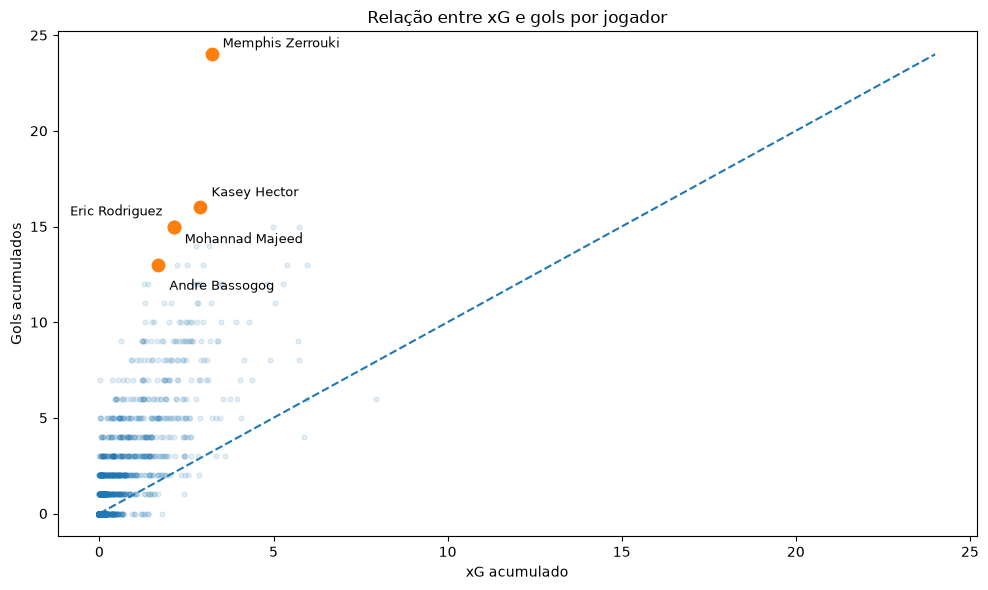

In [56]:
import matplotlib.pyplot as plt

# Selecionar os 5 principais outliers
principais_outliers = (
    resumo_xg_jogadores
    .assign(
        desvio_absoluto=resumo_xg_jogadores["over_performance"].abs()
    )
    .sort_values(
        by="desvio_absoluto",
        ascending=False
    )
    .head(5)
)

# Definir limite do gráfico
limite_maximo = max(
    resumo_xg_jogadores["xg_total"].max(),
    resumo_xg_jogadores["gols_totais"].max()
)

plt.figure(figsize=(10, 6))

# 1) Todos os jogadores: pontos bem discretos
plt.scatter(
    resumo_xg_jogadores["xg_total"],
    resumo_xg_jogadores["gols_totais"],
    s=12,
    alpha=0.12
)

# 2) Linha de referência y = x
plt.plot(
    [0, limite_maximo],
    [0, limite_maximo],
    linestyle="--",
    linewidth=1.5
)

# 3) Destacar os principais outliers
plt.scatter(
    principais_outliers["xg_total"],
    principais_outliers["gols_totais"],
    s=80
)

# 4) Rotular apenas os principais outliers
deslocamentos = [
    (8, 5),
    (8, 8),
    (8, -12),
    (-75, 8),
    (8, -18)
]

for deslocamento, (_, jogador) in zip(
    deslocamentos,
    principais_outliers.iterrows()
):
    plt.annotate(
        jogador["player_name"],
        (
            jogador["xg_total"],
            jogador["gols_totais"]
        ),
        xytext=deslocamento,
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("xG acumulado")
plt.ylabel("Gols acumulados")
plt.title("Relação entre xG e gols por jogador")
plt.grid(False)
plt.tight_layout()
plt.show()

### Conclusão do T3.1

O gráfico mostra os gols esperados (xG) na direção horizontal e os gols marcados na vertical. Cada ponto representa um jogador.

A linha tracejada indica onde os dois valores são iguais. Acima dela estão os jogadores que marcaram mais gols do que o esperado; abaixo, os que marcaram menos.

Para facilitar a leitura, coloquei o nome apenas dos cinco jogadores com as maiores diferenças entre gols marcados e esperados.

O gráfico ajuda a visualizar essa comparação, mas os problemas encontrados na base impedem tratar esses números como resultados reais confirmados.

## T3.2 — Comparação das notas por posição

Vou comparar as notas dos goleiros, defensores, meio-campistas e atacantes.

Além da média, vou observar quanto as notas variam e se existem valores muito acima ou abaixo dos demais em cada posição.

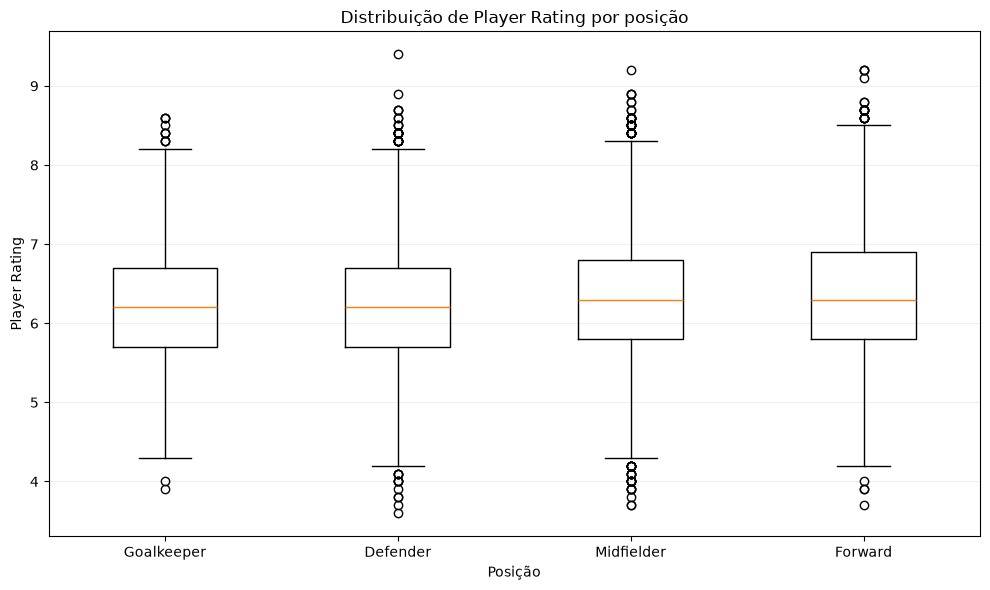

In [57]:
import matplotlib.pyplot as plt

ordem_posicoes = [
    "Goalkeeper",
    "Defender",
    "Midfielder",
    "Forward"
]

dados_boxplot = [
    df.loc[
        (df["position"] == posicao)
        & (df["minutes_played"] > 0),
        "player_rating"
    ].dropna()
    for posicao in ordem_posicoes

]

plt.figure(figsize=(10, 6))

plt.boxplot(
    dados_boxplot,
    tick_labels=ordem_posicoes,
    showfliers=True
)

plt.xlabel("Posição")
plt.ylabel("Player Rating")
plt.title("Distribuição de Player Rating por posição")

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [58]:
resumo_rating_posicao = (
    df[df["minutes_played"] > 0]
    .groupby("position")["player_rating"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median",
        desvio_padrao="std",
        minimo="min",
        maximo="max"
    )
    .round(2)
)

display(resumo_rating_posicao)

,quantidade,media,mediana,desvio_padrao,minimo,maximo
position,,,,,,
Defender,11484,6.24,6.2,0.72,3.6,9.4
Forward,7700,6.36,6.3,0.75,3.7,9.2
Goalkeeper,2100,6.21,6.2,0.72,3.9,8.6
Midfielder,10274,6.31,6.3,0.74,3.7,9.2


In [59]:
zeros_rating_por_posicao = (
    df.assign(
        rating_zero=df["player_rating"] == 0
    )
    .groupby("position")
    .agg(
        total_registros=("player_rating", "size"),
        ratings_zero=("rating_zero", "sum")
    )
)

zeros_rating_por_posicao["percentual_zero"] = (
    zeros_rating_por_posicao["ratings_zero"]
    / zeros_rating_por_posicao["total_registros"]
    * 100
)

display(zeros_rating_por_posicao)

,total_registros,ratings_zero,percentual_zero
position,,,
Defender,18900,7416,39.238095
Forward,12600,4900,38.888889
Goalkeeper,6300,4200,66.666667
Midfielder,16800,6526,38.845238


In [60]:
checagem_rating_zero = (
    df[df["player_rating"] == 0]
    .groupby("position")
    .agg(
        registros_rating_zero=("player_rating", "size"),
        rating_zero_com_0_minutos=(
            "minutes_played",
            lambda x: (x == 0).sum()
        ),
        rating_zero_com_minutos=(
            "minutes_played",
            lambda x: (x > 0).sum()
        )
    )
)

display(checagem_rating_zero)

,registros_rating_zero,rating_zero_com_0_minutos,rating_zero_com_minutos
position,,,
Defender,7416,7416,0
Forward,4900,4900,0
Goalkeeper,4200,4200,0
Midfielder,6526,6526,0


### Conclusão do T3.2

Antes de fazer o gráfico, conferi que todas as notas zero eram de registros em que o jogador não entrou em campo. Por isso, considerei apenas as notas de quem jogou.

As quatro posições tiveram resultados parecidos. As médias foram de 6,21 para goleiros a 6,36 para atacantes.

Pela comparação da tabela, os atacantes tiveram notas um pouco mais espalhadas em torno da média, mas a diferença para as outras posições foi pequena.

É esperado que as notas mudem de uma atuação para outra. Porém, essa análise não explica por que os atacantes tiveram a maior variação, nem permite dizer que uma posição teve desempenho claramente melhor.

## T3.3 — Quantidade de registros por seleção

Vou comparar quantos registros de cada seleção aparecem na base.

O desafio pede um gráfico de pizza 3D com 24 países. Antes de escolher como mostrar os dados, vou avaliar se esse formato facilita a comparação entre tantas seleções ou se outro tipo de gráfico seria mais claro.

In [61]:
quantidade_selecoes = df["team"].nunique()
quantidade_nacionalidades = df["nationality"].nunique()

print(
    "Quantidade de seleções diferentes em team:",
    quantidade_selecoes
)

print(
    "Quantidade de nacionalidades diferentes em nationality:",
    quantidade_nacionalidades
)

print("\nSeleções encontradas:")

print(
    sorted(df["team"].unique())
)

Quantidade de seleções diferentes em team: 48
Quantidade de nacionalidades diferentes em nationality: 48

Seleções encontradas:
['Algeria', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Brazil', 'Cameroon', 'Canada', 'Chile', 'Colombia', 'Costa Rica', 'Croatia', 'Denmark', 'Ecuador', 'Egypt', 'England', 'France', 'Germany', 'Ghana', 'Iran', 'Iraq', 'Italy', 'Jamaica', 'Japan', 'Mexico', 'Morocco', 'Netherlands', 'Nigeria', 'Panama', 'Peru', 'Poland', 'Portugal', 'Qatar', 'Saudi Arabia', 'Scotland', 'Senegal', 'Serbia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Tunisia', 'Turkey', 'Ukraine', 'United States', 'Uruguay', 'Uzbekistan']


### Avaliação do pedido de pizza 3D

A base tem 48 seleções, mas o pedido menciona 24 países. Por isso, é preciso definir quais seleções serão mostradas.

Uma pizza com tantas fatias fica difícil de comparar. O efeito 3D e as sombras também podem fazer algumas partes parecerem maiores do que são.

Eu escolheria um gráfico de barras, ordenado do maior para o menor, para facilitar a leitura.

Se fosse necessário manter a pizza 3D no pedido do gerente, explicaria essa dificuldade e apresentaria também o gráfico de barras.

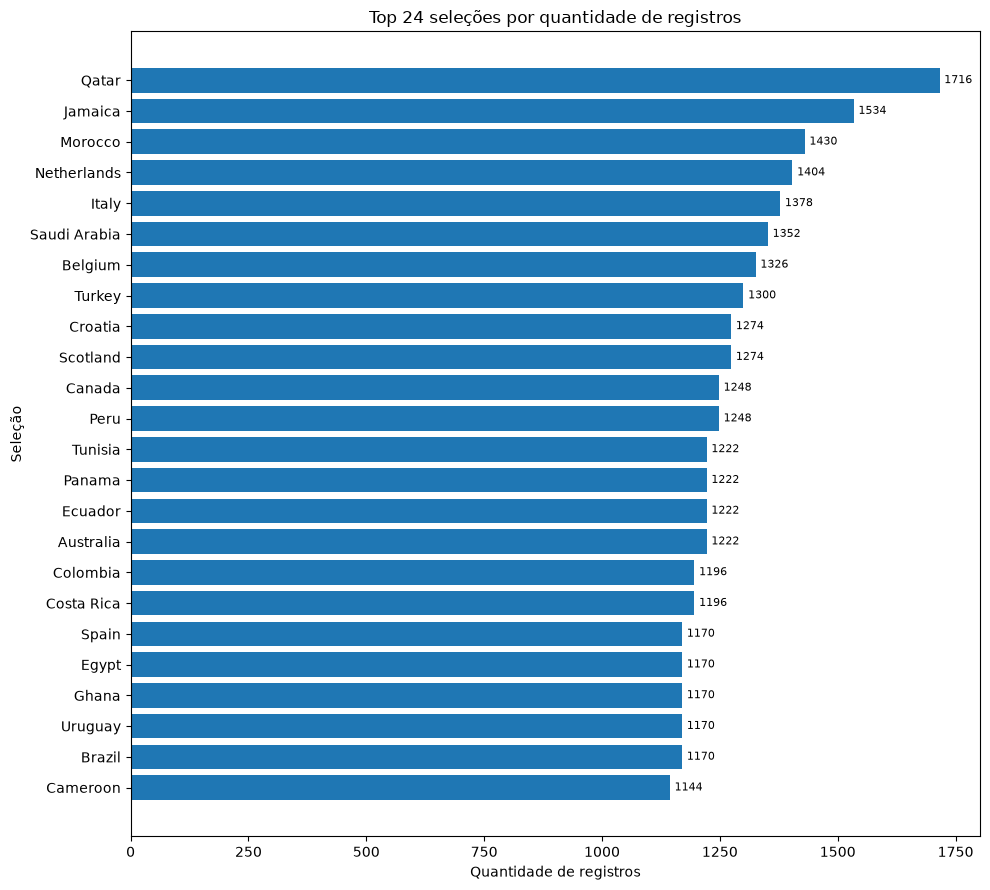

In [62]:
import matplotlib.pyplot as plt

# Selecionar as 24 seleções com maior quantidade de registros
registros_por_selecao = (
    df.groupby("team")
    .size()
    .nlargest(24)
    .sort_values(ascending=True)
)

# Criar o gráfico
plt.figure(figsize=(10, 9))

barras = plt.barh(
    registros_por_selecao.index,
    registros_por_selecao.values
)

# Adicionar a quantidade de registros no final de cada barra
for barra in barras:
    largura = barra.get_width()

    plt.text(
        largura + 10,
        barra.get_y() + barra.get_height() / 2,
        f"{int(largura)}",
        va="center",
        fontsize=8
    )

# Títulos e rótulos
plt.xlabel("Quantidade de registros")
plt.ylabel("Seleção")
plt.title("Top 24 seleções por quantidade de registros")

# Ajustar o espaço do gráfico
plt.tight_layout()

# Exibir
plt.show()


### Conclusão do T3.3

Como a base tem 48 seleções e o pedido menciona 24 países, escolhi mostrar as 24 seleções com mais registros.

Usei um gráfico de barras horizontais no lugar da pizza 3D porque fica mais fácil comparar os valores.

Qatar e Jamaica aparecem com as maiores quantidades de registros. Isso não significa que tenham mais jogadores diferentes ou melhor desempenho, apenas que aparecem em mais linhas da base.

A escolha das barras foi feita para deixar a comparação mais clara.

## T3.4 — Bônus: página interativa

Como etapa extra, foi criada uma página HTML para consultar o ranking de jogadores.

A página carrega os dados do arquivo `ranking_jogadores.json` e permite:

- escolher uma seleção;
- escolher quantos jogadores serão exibidos;
- atualizar o ranking;
- visualizar uma tabela com os principais dados;
- comparar os gols por 90 minutos em um gráfico de barras.

A página foi feita em um único arquivo HTML, sem depender de bibliotecas externas ou serviços online. O gráfico foi criado diretamente na página usando SVG.

O arquivo pode ser aberto pelo `index.html` usando o Live Server no VS Code.

# PARTE 4 — PERGUNTA DE NEGÓCIO

## T4.1 — Quem corre mais recebe notas melhores?

Vou comparar a distância percorrida pelos jogadores com as notas que receberam nas partidas.

Para isso, vou usar:

* a distância total percorrida (`distance_covered_km`);
* a distância percorrida em alta velocidade, chamada de sprint (`sprint_distance_km`);
* a nota do jogador na partida (`player_rating`).

A ideia é observar se quem corre mais costuma receber notas maiores. Mesmo que isso aconteça, não significa, por si só, que correr mais seja a causa de uma nota melhor.

In [63]:
dados_parte4 = df[
    df["minutes_played"] > 0
][
    [
        "distance_covered_km",
        "sprint_distance_km",
        "player_rating"
    ]
]

correlacoes_parte4 = (
    dados_parte4
    .corr()
    .round(3)
)

display(correlacoes_parte4)

,distance_covered_km,sprint_distance_km,player_rating
distance_covered_km,1.000,0.897,0.020
sprint_distance_km,0.897,1.000,0.022
player_rating,0.020,0.022,1.000


### Primeiros resultados da comparação

Nos registros analisados, quem percorreu uma distância maior também costumou percorrer mais distância em sprint. A correlação foi de 0,897: quanto mais perto de 1, mais forte é essa tendência de os dois valores aumentarem juntos.

Já na comparação com as notas, os resultados ficaram próximos de zero:

* distância total e nota: 0,020;
* distância em sprint e nota: 0,022.

Isso indica que não apareceu uma tendência clara de notas maiores para quem correu mais. Não significa que o esforço físico não tenha importância, apenas que essa comparação não mostrou essa relação.

Esses resultados também precisam ser vistos com cuidado por causa dos problemas já encontrados na base.

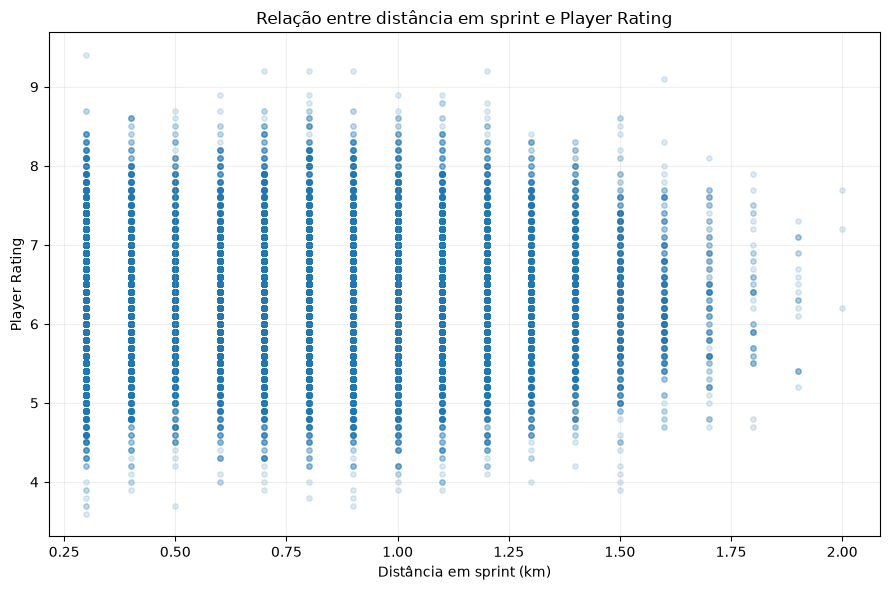

In [64]:
plt.figure(figsize=(9, 6))

plt.scatter(
    dados_parte4["sprint_distance_km"],
    dados_parte4["player_rating"],
    alpha=0.15,
    s=15
)

plt.xlabel("Distância em sprint (km)")
plt.ylabel("Player Rating")
plt.title("Relação entre distância em sprint e Player Rating")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Interpretação da análise

A comparação entre distância em sprint e nota teve uma correlação de 0,022, um valor próximo de zero. Nos dados analisados, não apareceu uma tendência clara de notas maiores para quem percorreu mais distância em sprint.

Essa comparação não permite dizer que correr mais causa uma mudança na nota. Os problemas encontrados na base também limitam a confiança nesse resultado.

### T4.2 — Resumo do resultado

Nesta base, não apareceu uma tendência clara de notas melhores para quem percorreu mais distância em sprint. A correlação foi de 0,022, próxima de zero, mas os problemas encontrados nos dados limitam a confiança nesse resultado.

### T4.3 — Pensamento crítico

Mesmo que a correlação entre distância em sprint e nota fosse de 0,8, não daria para afirmar que correr mais melhora a nota.

Isso mostraria que os dois valores costumam aumentar juntos, mas não provaria que um é a causa do outro.

A posição do jogador, o tempo em campo, sua função no time e a dificuldade da partida também poderiam ajudar a explicar o resultado.

Para entender se correr mais realmente influencia a nota, seria preciso investigar esses outros fatores.

# PARTE 5 — FECHAMENTO AO VIVO

## 5.1 — Decisão que eu mudaria com mais tempo

Com mais tempo, eu investigaria melhor os problemas nas partidas e nos minutos antes de montar as listas de jogadores e os totais por seleção.

Encontrei jogadores e seleções associados a muito mais partidas do que seria esperado em uma única Copa do Mundo. Isso afeta os totais de minutos, gols, assistências e distância percorrida.

Meu próximo passo seria entender de onde vêm esses registros e conferir quais partidas pertencem a cada jogador e data. Só depois dessa conferência eu apresentaria os resultados com mais confiança.

## 5.2 — Como a escolha dos registros muda a média

Vou comparar a média das notas por posição usando um gráfico de barras.

Primeiro, vou considerar apenas quem entrou em campo. Depois, vou incluir também quem não jogou.

Como os registros de quem não jogou têm nota zero, eles diminuem a média. Essa comparação mostra por que é importante escolher quais registros fazem sentido para a análise.

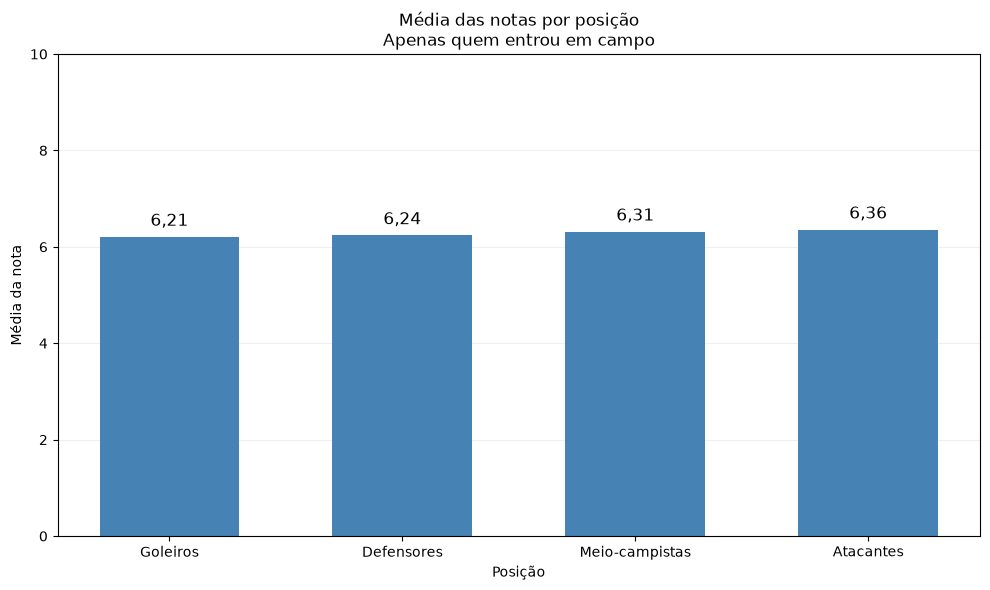

In [65]:
import matplotlib.pyplot as plt

# Altere apenas esta opção na apresentação:
# True = apenas quem entrou em campo.
# False = todos, incluindo quem não jogou.
APENAS_QUEM_JOGOU = True

# Escolher os registros sem alterar a base original.
if APENAS_QUEM_JOGOU:
    dados_ao_vivo = df.loc[df["minutes_played"] > 0].copy()
    titulo_ao_vivo = "Apenas quem entrou em campo"
else:
    dados_ao_vivo = df.copy()
    titulo_ao_vivo = "Incluindo quem não jogou"

# Definir a ordem e os nomes das posições.
posicoes_ao_vivo = [
    "Goalkeeper",
    "Defender",
    "Midfielder",
    "Forward"
]

nomes_ao_vivo = [
    "Goleiros",
    "Defensores",
    "Meio-campistas",
    "Atacantes"
]

# Calcular a média das notas de cada posição.
medias_ao_vivo = (
    dados_ao_vivo
    .groupby("position")["player_rating"]
    .mean()
    .reindex(posicoes_ao_vivo)
)

# Criar o gráfico de barras.
fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.bar(
    nomes_ao_vivo,
    medias_ao_vivo.values,
    color="steelblue",
    width=0.6
)

# Escrever a média acima de cada barra.
for barra, media in zip(barras, medias_ao_vivo.values):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        media + 0.15,
        f"{media:.2f}".replace(".", ","),
        ha="center",
        va="bottom",
        fontsize=12
    )

ax.set_title(
    f"Média das notas por posição\n{titulo_ao_vivo}"
)
ax.set_xlabel("Posição")
ax.set_ylabel("Média da nota")

# Manter a mesma escala nas duas situações.
ax.set_ylim(0, 10)
ax.set_yticks(range(0, 11, 2))

ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

### O que essa comparação mostra

As médias diminuem quando incluo os registros de quem não entrou em campo, porque eles têm nota zero.

Essa queda não significa que os jogadores passaram a jogar pior. O que mudou foi a escolha dos registros usados no cálculo.

Para comparar as notas de desempenho, faz mais sentido considerar apenas quem jogou.

## 5.3 — O que não consegui validar

Não consegui confirmar se as partidas e os minutos registrados representam uma única Copa do Mundo. Encontrei jogadores em várias partidas no mesmo dia e totais de minutos acima do esperado.

Para conferir isso, eu buscaria a explicação de como a base foi criada e compararia alguns registros de jogadores, partidas e datas com a fonte original.

Até esclarecer esses pontos, eu usaria os resultados apenas para explorar os dados, sem apresentá-los como resultados reais confirmados do torneio.